Sabina Gallo

ID: 535785

Machine Learning Module 1 Final Project

# Predicting Patient No\-shows in Healthcare Appointments

Missed medical appointments, commonly referred to as no shows, represent a major inefficiency in healthcare systems, leading to wasted resources, longer waiting times and reduced quality of care\.

The objective of this project is to analyze a real\-world healthcare dataset containing information about patients and their scheduled medical appointments, with the aim of predicting whether a patient will attend the appointment or not\.

By leveraging machine learning techniques, the project seeks to identify patterns and risk factors associated with no\-show behavior and potentially support healthcare providers in improving appointment management\. 

### Project Objective

From a machine learning perspective, this project addresses a binary classification problem aimed at predicting whether a patient will attend a scheduled medical appointment or not\.

The target variable is No\_show, derived from the variable Showed\_up\. It encodes patient attendance as:

- 0: patient attended the appointment

- 1: patient did not attend \(No\_show\)

This project follows a standard supervised machine learning workflow that includes:

- data exploration 

- preprocessing and feature engineering

- model selection

- hyperparameter optimization

- performance evaluation

### Dataset Description

The dataset used in this project contains information about 110\.527 medical appointments, each corresponding to a single scheduled visit for a patient in the Brazilian public healthcare system\. A total of 15 variables describe patient characteristics and appointment details\. 

The dataset includes a mix of numerical, categorical and binary features\. Patient\-related information includes demographic data such as age and gender, as well as medical conditions like hypertension, diabetes, alcoholism and disability\.                                                                                                          

Appointment\-related features describe scheduling information, such as the appointment date, the scheduling date, the neighborhood where the appointment takes place and whether reminder SMS messages were received\.

One relevant socio\-economic indicator is the Scholarship variable, which denotes whether the patient is enrolled in a social welfare program \("Bolsa Familia"\)\. This feature may capture socio\-economic factors associated with appointment attendance\. 

### Dataset Source 

The dataset used in this project is publicly available on Kaggle:

Medical Appointment No Shows Dataset: https://www\.kaggle\.com/datasets/joniarroba/noshowappointments

It contains anonymized data collected from medical appointments in Brazil and is commonly used for research on healthcare appointment attendance and predictive modeling\.

### Libraries and Data Loading

Specific library versions are explicitly enforced to guarantee reproducibility and to avoid known compatibility issues between scikit\-learn, imbalanced\-learn and mlxtend, which are jointly used for pipeline construction, resampling and feature selection\.

In [3]:
# import all libraries as in the original code
import pandas as pd
import numpy as np
import itertools

import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform
from scipy.stats import randint, uniform
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import matthews_corrcoef
from sklearn.model_selection import learning_curve, StratifiedKFold

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, recall_score

from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.base import clone

from imblearn.pipeline import Pipeline as IMBPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

import sklearn
import imblearn
import inspect
import shap


The dataset is loaded into a pandas Dataframe to enable structured data manipulation and integration with the scikit\-learn pipeline used in subsequent stages\.

In [4]:
healthcare = pd.read_csv('data/healthcare.csv') # Load the dataset from the CSV file into a pandas DataFrame
healthcare.head() # Display the first rows of the dataset


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


The first rows of the dataset are displayed to verify that the file has been imported correctly and to obtain an initial overview of the available variables\.

### Rename incorrect column name

In [5]:
# Correct known spelling inconsistency in the original dataset
healthcare = healthcare.rename(columns={
    "Hipertension": "Hypertension" # Column "Hipertension" is renamed to "Hypertension"
})


A spelling inconsistency in the original dataset is corrected to ensure naming consistency throughout the analysis\.

Standardizing column names is important to avoid ambiguity during preprocessing, feature engineering and pipeline construction, especially when variables are repeatedly referenced across different stages of the workflow\.

### Convert date columns to datetime

In [6]:
# Convert date columns to datetime format
healthcare["ScheduledDay"] = pd.to_datetime(healthcare["ScheduledDay"])
healthcare["AppointmentDay"] = pd.to_datetime(healthcare["AppointmentDay"])


Converting date columns to datetime ensures correct handling of temporal information and enables future feature extraction such as waiting time between scheduling and appointment\.

# Exploratory Data Analysis \(EDA\)

The exploratory data analysis \(EDA\) aims not to only understand the dataset, but also to identify patterns and potential predictors of no\-show behavior\. The insights derived from this analysis will guide preprocessing choices and modeling decisions\.

### Dataset Structure

In [7]:
healthcare.info() # Display dataset structure: columns, data types and missing values


<class 'pandas.DataFrame'>
RangeIndex: 106987 entries, 0 to 106986
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   PatientId       106987 non-null  float64       
 1   AppointmentID   106987 non-null  int64         
 2   Gender          106987 non-null  str           
 3   ScheduledDay    106987 non-null  datetime64[us]
 4   AppointmentDay  106987 non-null  datetime64[us]
 5   Age             106987 non-null  int64         
 6   Neighbourhood   106987 non-null  str           
 7   Scholarship     106987 non-null  bool          
 8   Hypertension    106987 non-null  bool          
 9   Diabetes        106987 non-null  bool          
 10  Alcoholism      106987 non-null  bool          
 11  Handcap         106987 non-null  bool          
 12  SMS_received    106987 non-null  bool          
 13  Showed_up       106987 non-null  bool          
 14  Date.diff       106987 non-null  int64         

This initial inspection provides a global overview of  the dataset structure, including feature types, data formats and overall size, which is necessary to design an appropriate preprocessing strategy\. 

The output also shows the number of non\-null entries for each variable\. In this case, all features report the same number of observations, indicating that the original dataset does not contain naturally occurring missing values\.

The information provided by this step is also useful to distinguish between numerical features, categorical variables and boolean indicators, allowing an early identification of which preprocessing techniques \(scaling, encoding, imputation\) will be required\.

### Summary Statistics

In [8]:
healthcare.describe(include='all')

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
count,1.069870e+05,1.069870e+05,106987,106987,106987,106987.000000,106987,106987,106987,106987,106987,106987,106987,106987,106987.000000
unique,NaN,NaN,2,NaN,NaN,NaN,81,2,2,2,2,2,2,2,NaN
top,NaN,NaN,F,NaN,NaN,NaN,JARDIM CAMBURI,False,False,False,False,False,False,True,NaN
freq,NaN,NaN,70118,NaN,NaN,NaN,7586,96178,85186,99044,103627,104747,72402,85307,NaN
mean,1.472814e+14,5.675434e+06,NaN,2016-05-08 21:18:53.330217,2016-05-19 01:18:58.041070,38.316085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.166721
min,3.921784e+04,5.030230e+06,NaN,2015-11-10 00:00:00,2016-04-29 00:00:00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.000000
25%,4.173523e+12,5.640490e+06,NaN,2016-04-29 00:00:00,2016-05-09 00:00:00,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,3.172463e+13,5.680744e+06,NaN,2016-05-10 00:00:00,2016-05-18 00:00:00,38.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000
75%,9.433600e+13,5.725634e+06,NaN,2016-05-20 00:00:00,2016-05-31 00:00:00,56.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.000000
max,9.999816e+14,5.790484e+06,NaN,2016-06-08 00:00:00,2016-06-08 00:00:00,115.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179.000000


Summary statistics provide a first quantitative description of feature distributions, highlighting ranges, central tendencies and category frequencies\.

For numerical features, this includes measures such as mean, standard deviation and quantiles, which help identify the range and dispersion of the values\.

For categorical variables, the output shows the number of unique categories, the most frequent value and its frequency\.

Some entries may appear as missing because certain statistical measures are not applicable to specific data types\. This does not indicate the presence of actual NaN values in the dataset at this stage\.

In addition, negative values are observed in the variable Date\.diff, indicating cases where the appointment date appears earlier than the scheduling date\.

Since this situation is not realistic in a healthcare context, these observations are considered as data inconsistencies and are removed from the dataset to avoid introducing noise into the modeling process\.

In [9]:
# Remove unrealistic negative waiting times
healthcare = healthcare[healthcare["Date.diff"] >= 0]

This cleaning step is performed before introducing artificial missing values in order to ensure that inconsistencies in the original dataset are addressed first\. 

In [10]:
healthcare["Date.diff"].describe()

count    106982.000000
mean         10.167290
std          15.263631
min           0.000000
25%           0.000000
50%           4.000000
75%          14.000000
max         179.000000
Name: Date.diff, dtype: float64

## Artificial Introduction of Missing Values

The original dataset does not contain naturally occurring missing values, which represents an idealized scenario that is rarely observed in real\-world healthcare data\. In practice, missing information is common due to reporting delays, human errors, or incomplete data collection processes\.

For this reason, missing values are artificially introduced in a controlled manner to simulate realistic data imperfections and to evaluate the robustness of the preprocessing pipeline\.

This step is not intended to degrade data quality, but to create a more realistic experimental setting in which different imputation strategies can be meaningfully assessed\.

Missingness is generated under the Missing Completely At Random \(MCAR\) assumption, meaning that the probability of a value being missing is independent of both observed and unobserved data\.

### Convert Boolean Variables and Define Missingness Function

Boolean variables are converted to float to enable the representation of missing values \(NaN\), as integer types cannot directly encode missingness in standard pandas structures\.

A custom function is defined to inject missing values into selected features using random sampling without replacement\. This ensures a uniform distribution of missing values across observations and guarantees reproducibility through a fixed random seed\.

The design follows an MCAR mechanism, providing a controlled baseline scenario for evaluating different imputation strategies\.

In [11]:
# Convert boolean/binary variables to float so they can store NaN values
bool_cols = ["Alcoholism", "Diabetes", "Hypertension", "Handcap",
             "SMS_received", "Scholarship"]

healthcare[bool_cols] = healthcare[bool_cols].astype(float)

def introduce_missing_mcar(df_in, missing_rates, seed=42):
    """
    Introduce missing values (NaN) into selected columns of a DataFrame
    under the MCAR assumption.
    """
    rng = np.random.default_rng(seed)
    df_out = df_in.copy()
    n = len(df_out)

    for col, rate in missing_rates.items():
        n_missing = int(n * rate)
        idx = rng.choice(df_out.index, size=n_missing, replace=False)
        df_out.loc[idx, col] = np.nan

    return df_out

### Introduce Heterogeneous Missingness Across Selected Variables

Missing values are introduced with variable\-specific rates to simulate heterogeneous data incompleteness, reflecting realistic patterns observed in healthcare datasets\.

Lower missing rates are assigned to clinical variables such as Alcoholism, Diabetes, Hypertension and Handcap, as these are typically recorded more reliably\.

Higher missing rates are applied to contextual and socio\-economic features such as Neighbourhood, SMS\_received, and Scholarship, which are more prone to incomplete recording in real\-world settings\.

This non\-uniform missingness structure increases the realism of the dataset and enables a more meaningful evaluation of preprocessing and modeling choices\.

In [12]:
missing_plan = {
    "Alcoholism": 0.01,
    "Diabetes": 0.01,
    "Hypertension": 0.01,
    "Handcap": 0.01,
    "Gender": 0.03,
    "Age": 0.02,
    "Neighbourhood": 0.08,
    "SMS_received": 0.08,
    "Scholarship": 0.10
}

healthcare_missing = introduce_missing_mcar(healthcare, missing_plan, seed=42)

## Data Inspection

After introducing artificial missing values, the dataset is inspected again in order to verify the new distribution of missingness across features\. This step is useful to confirm that the intended missingness mechanism has been correctly applied before proceeding with visualization and preprocessing\.

In [13]:
healthcare_missing.shape

(106982, 15)

The dataset consists of 106,982 observations and 15 features, including both numerical and categorical variables\.

In [14]:
healthcare_missing.info()

<class 'pandas.DataFrame'>
Index: 106982 entries, 0 to 106986
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   PatientId       106982 non-null  float64       
 1   AppointmentID   106982 non-null  int64         
 2   Gender          103773 non-null  str           
 3   ScheduledDay    106982 non-null  datetime64[us]
 4   AppointmentDay  106982 non-null  datetime64[us]
 5   Age             104843 non-null  float64       
 6   Neighbourhood   98424 non-null   str           
 7   Scholarship     96284 non-null   float64       
 8   Hypertension    105913 non-null  float64       
 9   Diabetes        105913 non-null  float64       
 10  Alcoholism      105913 non-null  float64       
 11  Handcap         105913 non-null  float64       
 12  SMS_received    98424 non-null   float64       
 13  Showed_up       106982 non-null  bool          
 14  Date.diff       106982 non-null  int64         
dtyp

The info\(\) function provides a detailed overview of the dataset structure, including the number of non\-null values for each variable and their associated data types\.

From this output it is possible to identify the different types of variables present in the dataset:

- Numerical variables, such as Age and Date\.diff

- Categorical variables, such as Gender and Neighbourhood

- Boolean indicators, representing medical conditions or appointment characteristics \(e\.g\., Hypertension, Diabetes, Alcoholism, SMS\_received\)

- The target variable, Showed\_up, stores as a boolean value

### Missing values

In order to better understand the distribution of missing values across the dataset, the number and percentage of missing observations for each feature are computed\.

This allows identifying which variables contain the highest proportion of missing values and will therefore require more careful handling during preprocessing\.

In [15]:
# Missing values analysis (count and percentage per feature)
missing_count = healthcare_missing.isna().sum()
missing_percent = (missing_count / len(healthcare_missing)) * 100

missing_summary = (
    pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    })
    .sort_values("missing_percent", ascending=False)
)

missing_summary


,missing_count,missing_percent
Scholarship,10698,9.999813
SMS_received,8558,7.999477
Neighbourhood,8558,7.999477
Gender,3209,2.999570
Age,2139,1.999402
Hypertension,1069,0.999234
Diabetes,1069,0.999234
Alcoholism,1069,0.999234
Handcap,1069,0.999234
PatientId,0,0.000000


The missing value analysis shows that missingness is not uniformly distributed across features\. 

In particular, Neighborhood \(15%\), Scholarship \(20%\) and SMS\_received\(15%\) contain a very large amount of missing values, while Gender\(6%\) and Age\(2%\) have a moderate level of missingness\. The remaining clinical binary features \(e\.g\., Hypertension, Diabetes, Alcoholism,  Handcap\) present only a small fraction of missing values \(2%\)\. 

This step is essential because most machine learning algorithms cannot handle missing data directly, therefore a clear strategy \(imputation or removal\) must be defined later in the preprocessing pipeline\.

### Visualizing Missing Values

To complement the quantitative analysis, the missingno library is used to visually inspect the location and pattern of missing values in the dataset\.

This visualization helps verify whether missing values appear randomly distributed or concentrated in specific variables\.

<Axes: >

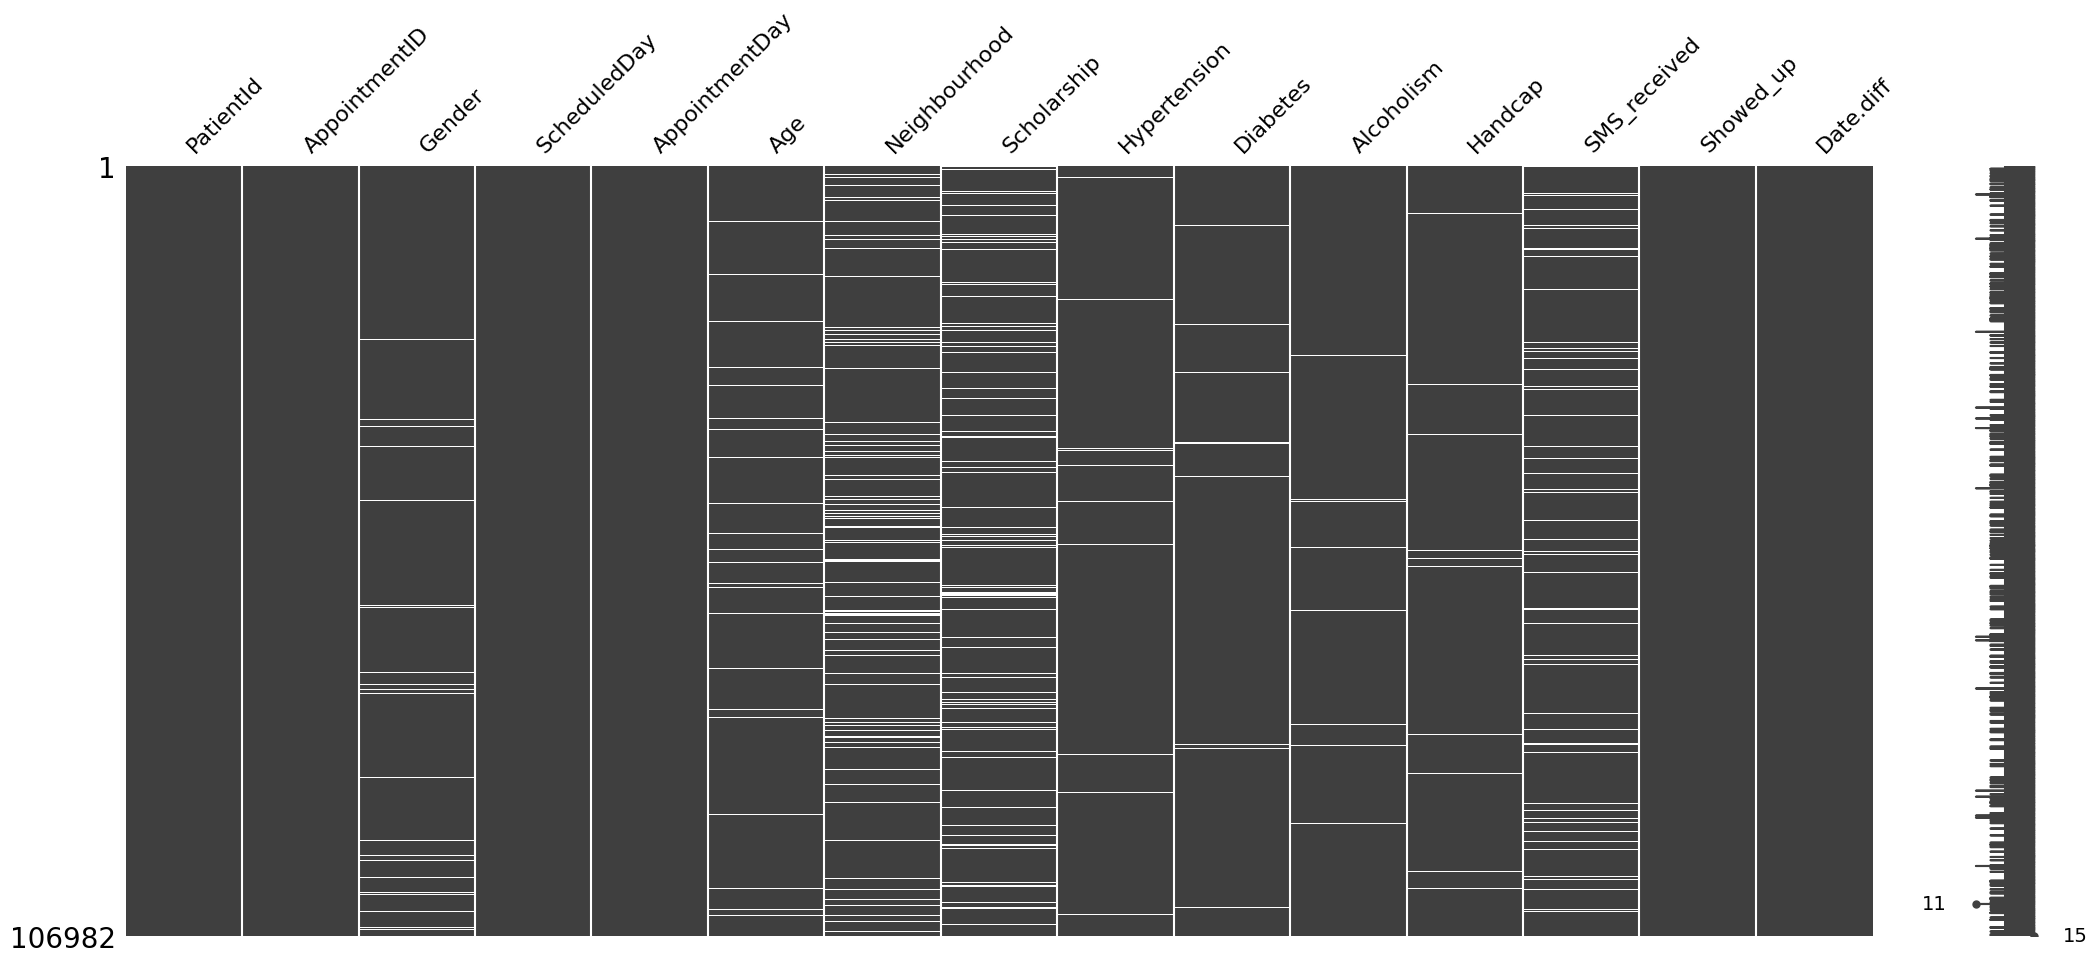

In [16]:
msno.matrix(healthcare_missing)

The missingness matrix visually confirms the previous quantitative analysis: missing values are concentrated in a subset of variables \(especially Neighborhood, Scholarship and SMS\_received\), while other columns are almost complete\.

### Target Variable Distribution

Before examining feature\-level patterns, it is essential to inspect the distribution of the target variable, since class balance directly affects both model evaluation and modeling choices\. 

In the original dataset, appointment attendance is stored in the variable Showed\_up\. For clarity and interpretability, the analysis uses the derived binary variable No\_show, defined as:

- 0: the patient attended the appointment

- 1: the patient did not attend the appointment

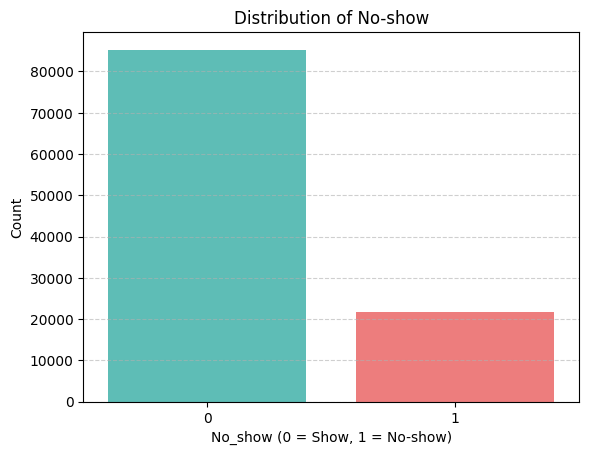

In [17]:
# Bar plot of the target variable distribution
healthcare["No_show"] = (healthcare["Showed_up"] == False).astype(int)

sns.countplot(
    data=healthcare,
    x="No_show",
    palette=["#4ECDC4", "#FF6B6B"]
)

plt.title('Distribution of No-show', fontsize=12)
plt.xlabel("No_show (0 = Show, 1 = No-show)")
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

The target distribution reveals a clear class imbalance: the majority of patients attend their appointment, while no\-shows represent a substantially smaller proportion of the dataset\. This confirms that the prediction task is an imbalanced binary classification problem\.

From a modeling perspective, this has two immediate implications\. First, overall accuracy would be misleading, since a naive model predicting only the majority class would already obtain a high score\. Second, the evaluation phase should prioritize metrics that better reflect minority class performance, such as precision, recall, F1\-score and confusion matrix analysis\. This class imbalance also justifies the adoption of stratified validation and, where appropriate, resampling techniques such as oversampling or SMOTE\.

## Distribution of Numerical Features

After analyzing the target variable, the next step is to examine the numerical predictors\. In this dataset, the truly numerical features are Age and Date\.diff\.

The variable Date\.diff represents the number of days between scheduling and the actual appointment date\. Since this quantity is easier to interpret behaviorally, it will be referred to as waiting time throughout the discussion, while keeping the original name in the code\.

Although PatientId and AppointmetID are numerical in format, they are identifiers rather than meaningful predictors\. For this reason, they are excluded from feature\-level analysis and from the modeling pipeline\.

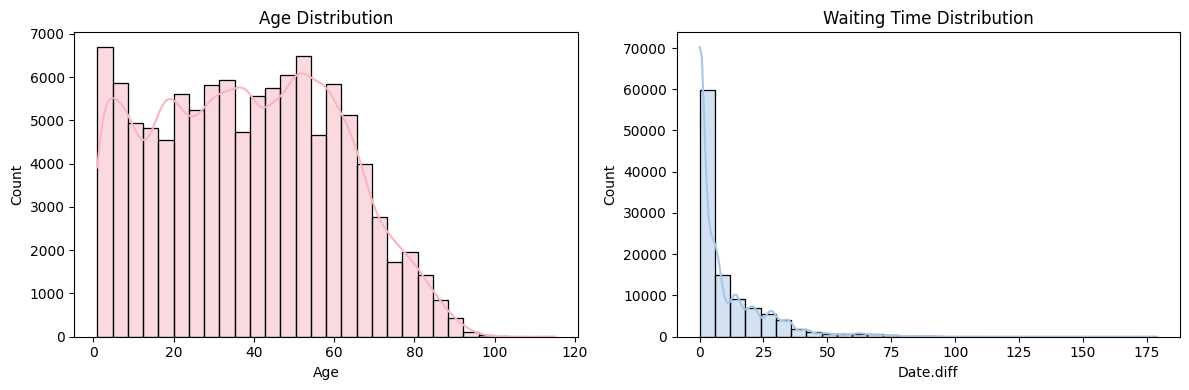

In [18]:
# Distribution of numerical features
num_cols = ["Age", "Date.diff"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    healthcare["Age"],
    bins=30,
    kde=True,
    color="#F8B6C1",
    edgecolor="black",
    ax=axes[0]
)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.histplot(
    healthcare["Date.diff"],
    bins=30,
    kde=True,
    color="#A7C7E7",
    edgecolor="black",
    ax=axes[1]
)
axes[1].set_title("Waiting Time Distribution")
axes[1].set_xlabel("Date.diff")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The age distribution is reasonably spread across the adult population, with a mild concentration in middle age groups and no major structural irregularities\. This suggests that Age is a stable demographic feature that may contribute useful information, although its predictive role is not expected to be dominant on its own\.

By contrast, waiting time is strongly right\-skewed\. Most appointments are scheduled within a relatively short time window, while\. a smaller subset exhibits much longer delays\. This shape is informative from both a statistical and behavioral standpoint\. Statistically, it suggests that the feature should be handled carefully during preprocessing, since the distribution is clearly non\-Gaussian\. Behaviorally, it indicates that delays between booking and visit may play a relevant role in patient adherence\.

From a modeling perspective, the skewness of waiting time suggests that robust handling may be preferable to methods that assume symmetric distributions\. In particular, this feature may benefit from robust preprocessing or discretization, especially if its relationship with the target turns out to be non\-linear\.

### Outliers Analysis of Numerical Features

Outlier analysis is relevant only for numerical variables\. For this reason, it is conducted on Age and Date\.diff, and not on binary or categorical features\.

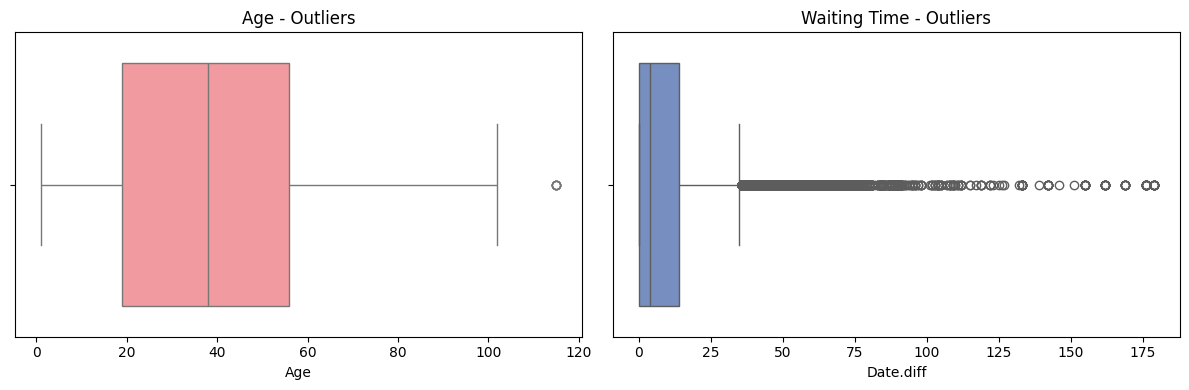

In [19]:
# Outliers
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(x=healthcare["Age"], color="#FF8C94", ax=axes[0])
axes[0].set_title("Age - Outliers")

sns.boxplot(x=healthcare["Date.diff"], color="#6A89CC", ax=axes[1])
axes[1].set_title("Waiting Time - Outliers")

plt.tight_layout()
plt.show()

The boxplots show that Age does not present problematic outliers, with values remaining within a plausible human range\. Therefore, no specific corrective treatment appears necessary for this variable\.

Waiting time, on the other hand, displays several extreme values corresponding to very long delays between scheduling and appointment\. These observations may represent rare but realistic cases, rather than errors, so they should be not remoed automatically\. Eliminating them could discard meaningful information and weaken the behavioral interpretation of the ffeature\.

For this reason, the most appropriate strategy is to retain these values and address their effect through robust preprocessing or discretization rather than through aggressive filtering\.

### Waiting Time and No\-show Behavior

Since waiting time appears both skewed and potentially informative, the next step is to examine its relationship with the target variable\. To improve interpretability, waiting time is grouped into clinically and operationally meaningful intervals\.

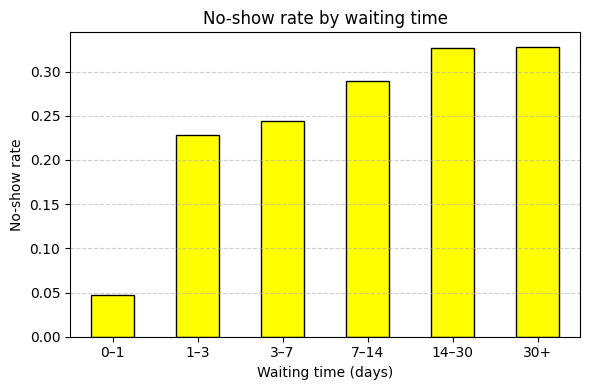

In [20]:
# Waiting time vs no-show analysis

# Create waiting time bins (in days)
bins = [0, 1, 3, 7, 14, 30, healthcare["Date.diff"].max()]
labels = ["0–1", "1–3", "3–7", "7–14", "14–30", "30+"]

healthcare["Waiting_time_bin"] = pd.cut(
    healthcare["Date.diff"],
    bins=bins,
    labels=labels,
    right=False
)

# Compute no-show rate per bin
no_show_by_wait = (
    healthcare
    .groupby("Waiting_time_bin")["Showed_up"]
    .apply(lambda x: (x == False).mean())
)

plt.figure(figsize=(6, 4))
no_show_by_wait.plot(
    kind="bar",
    color="yellow",
    edgecolor="black"
)
plt.title("No-show rate by waiting time")
plt.xlabel("Waiting time (days)")
plt.ylabel("No-show rate")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


A clear and monotonic relationship emerges between waiting time and no\-show probability\. Patients scheduled within one day show very low no\-show rates, whereas the probability of missing the appointment rises steadily as waiting time increases\. Appointments scheduled more than two weeks in advance reach substantially higher no\-show rates than short\-notice appointments\.

This is one of the strongest patterns observed in the exploratory analysis\. It suggests that waiting time is not merely a skewed numerical feature, but a highly informative predictor associated with a patient commitment, scheduling friction, and the increasing likelihood of competing priorities over time\.

From a modeling perspective, this makes waiting time a key feature to retain\. Moreover, the monotonic but non\-linear pattern supports the idea that both the raw numerical version and a discretized version may be valuable, depending on the model family adopted\.

### Age and No\-show Behavior

To assess whether Age provides predictive signal beyond its marginal distribution, the no\-show rate can be compared across age groups\.

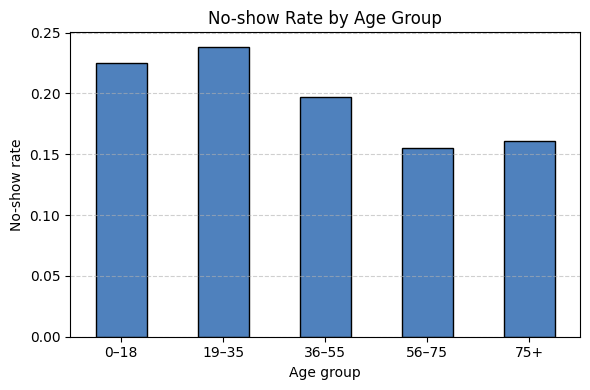

In [21]:
# Age vs no-show analysis
age_bins = [0, 18, 35, 55, 75, healthcare["Age"].max() + 1]
age_labels = ["0–18", "19–35", "36–55", "56–75", "75+"]

tmp_age = healthcare[["Age", "No_show"]].dropna(subset=["Age"]).copy()

tmp_age["Age_bin"] = pd.cut(
    tmp_age["Age"],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

no_show_by_age = (
    tmp_age
    .groupby("Age_bin")["No_show"]
    .mean()
)

plt.figure(figsize=(6, 4))

no_show_by_age.plot(
    kind="bar",
    color="#4F81BD",
    edgecolor="black"
)

plt.title("No-show Rate by Age Group")
plt.xlabel("Age group")
plt.ylabel("No-show rate")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Age shows only moderate variation in no\-show rates across groups\. Younger and middle\-aged patients display slighlty higher non\-attendance rates than older groups, but the oveerall differences remain contained and do not suggest a strong monotonic pattern\.

This indicates that Age is not a dominant standalone predictor of no\-show behavior\. Nevertheless, it may still contribute useful information when combined with scheduling or socio\-demographic features\. In other words, Age is worht retaining, but its predictive effect is more likely to emerge through interactions than as a primary driver\.

### Correlation between Numerical Features

Finally, the linear relationship between the numerical predictors is inspected to assess whether redundancy or multicollinearity may be an issue\.

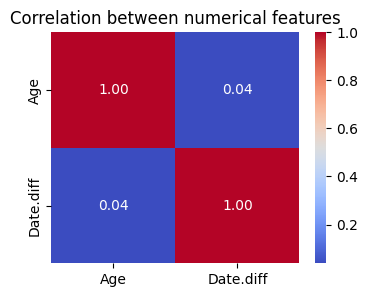

In [22]:
plt.figure(figsize=(4,3))

sns.heatmap(
    healthcare[["Age", "Date.diff"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation between numerical features")
plt.show()

The correlation heatmap shows a very weak linear relationship between Age and Date\.diff \(correlation = 0\.4\), indicating that these variables capture largely independent aspects of the data\. As a result, no multicollinearity issues are expected among the numerical features and both variables can be retained without the need for dimensionality reduction or feature removal\.

### Distribution of categorical features

After analyzing numerical variables, the focus shifts to categorical features\. The objectivee is to examine their distributions, identify class imbalance and missing values, and anticipate preprocessing challenges such as encoding and imputation\.

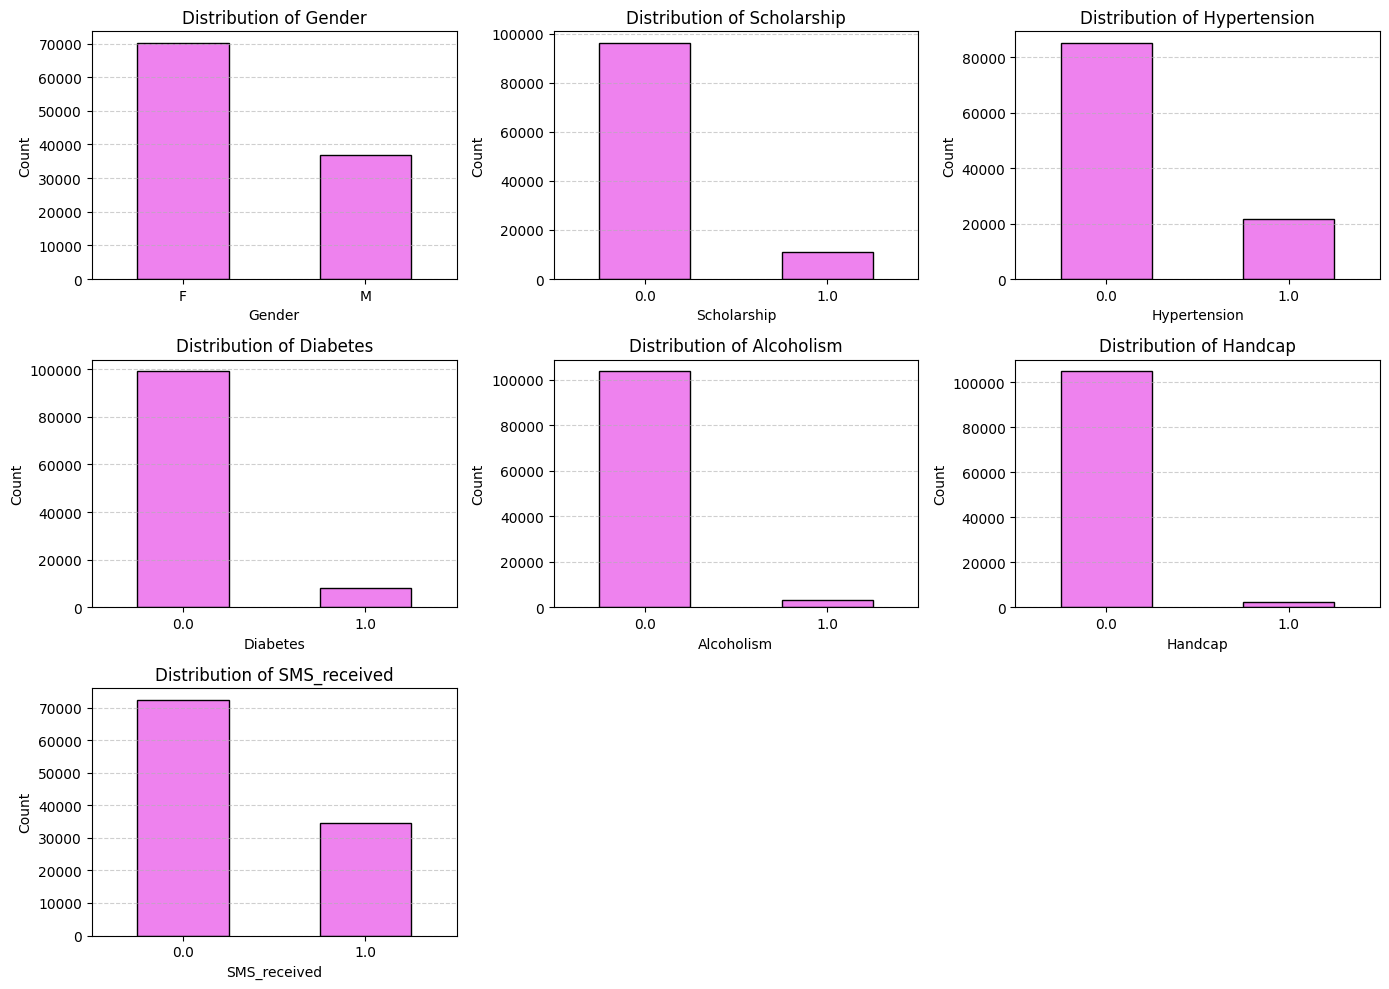

In [23]:
# Categorical features with few categories
cat_cols_small = [
    "Gender",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received"
]

plt.figure(figsize=(14, 10)) # create large figure to display multiple plots

for i, col in enumerate(cat_cols_small, start=1): # loop over features with subplot index
    plt.subplot(3, 3, i) # arrange plots in 3x3 grid
    healthcare[col].value_counts(dropna=False).plot(
        kind="bar",                       # barplot to visualize category frequencies
        color="violet",
        edgecolor="black"
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)                             # feature name on x-axis
    plt.ylabel("Count")                          # frequency on y-axis
    plt.xticks(rotation=0)                       # keep lables readable
    plt.grid(axis="y", linestyle="--", alpha=0.6)
 
plt.tight_layout() # avoid overlapping between subplots
plt.show()


The distributions highlight several important patterns\. Most clinical variables \(Hypertension, Diabetes, Alcoholism, Handicap\) are highly imbalanced, with the majority of patients not presenting the condition\. This suggests that these variables may have limited standalone predictive power, but could still contribute when combined with other features\.

A key aspect emerging from this analysis is the presence of missing values, explicitly visible as "NaN" categories in some variables such as Gender, Scholarship and SMS\_received\. Rather than being ignored, these missing values represent an important data quality issue that must be addressed during preprocessing, either through imputation or by introducing a dedicated category\.

Overall, this step confirms that categorical variables require careful handling to avoid introducing bias and to ensure meaningful encoding\.

### SMS Reminders and No\-show Behavior

Among categorical features, SMS\_received represents a direct operational intervention aimed at reducing no\-show rates\. For this reason, it is analyzed first\.

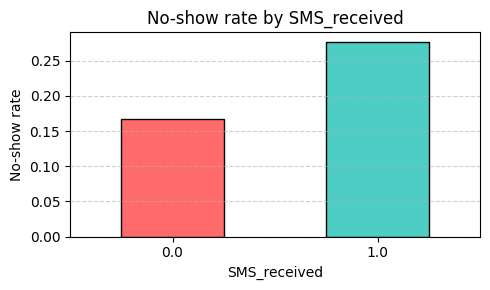

In [24]:
sms_no_show = (
    healthcare
    .groupby("SMS_received")["No_show"]    # group by SMS and compute target
    .mean()                                # mean = no_show rate
)

plt.figure(figsize=(5, 3)) # compact figure for single comparison

sms_no_show.plot(
    kind="bar",            # bar plot for comparison  
    color=["#FF6B6B", "#4ECDC4"],
    edgecolor="black"
)

plt.title("No-show rate by SMS_received")
plt.xlabel("SMS_received")
plt.ylabel("No-show rate")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

The results reveal a counterintuitive pattern: patients who received an SMS reminder exhibit a higher no\-show rate than those who did not\.

Rather than indicating inefficiency of reminders, this likely reflects a selection bias\. SMS notifications may be preferentially sent to patients who are already considered at higher risk of missing their appointments\.

From a modeling perspective, this implies that SMS\_received should not be interpreted as a causal feature, but rather as a proxy for underlying patient risk\. The variable is therefore informative, but its effect must be interpreted cautiously\.

### Socio\-economic Factor: Scholarship

The Scholarship variable acts as a proxy for socio\-economic vulnerability and may capture structural barriers to attendance\.

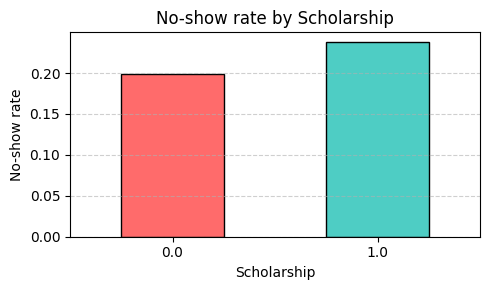

In [25]:
sch_no_show = (
    healthcare
    .groupby("Scholarship")["No_show"].  # group by socio-economic indicator
    mean()
)

plt.figure(figsize=(5, 3))

sch_no_show.plot(
    kind="bar",
    color=["#FF6B6B", "#4ECDC4"],
    edgecolor="black"
)

plt.title("No-show rate by Scholarship")
plt.xlabel("Scholarship")
plt.ylabel("No-show rate")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Patients receiving a scholarship exhibit a slightly higher no\-show rate compared to non\-recipients\. Although the difference is moderate, it suggests that socio\-economic factors may play a role in appointment adherence\.

From a modeling standpoint, Scholarship may not be a strong standalone predictor, but it is likely to contribute in interaction with other variables such as waiting time or neighborhood\.

### Clinical Conditions and No\-show Behavior

Clinical variables share a similar binary structure\. Instead of analyzing them separately, they are summarized in a single comparative view\.

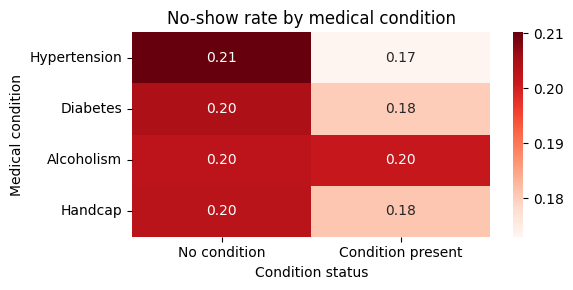

In [26]:
medical_cols = ["Hypertension", "Diabetes", "Alcoholism", "Handcap"]

no_show_rates = {}

for col in medical_cols:
    rate = (
        healthcare
        .groupby(col)["No_show"]
        .mean()
        .reindex([0, 1])
    )
    no_show_rates[col] = rate.values

medical_df = pd.DataFrame(
    no_show_rates,
    index=["No condition", "Condition present"]
).T

plt.figure(figsize=(6, 3))

sns.heatmap(
    medical_df,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("No-show rate by medical condition")
plt.xlabel("Condition status")
plt.ylabel("Medical condition")

plt.tight_layout()
plt.show()

Overall, the no\-show rates remain in a narrow range across conditions, suggesting that these clinical variables alone provide limited discriminative power\. Some conditions show only small differences between patients with and without the condition, indicating that medical status may not be a strong standalone driver of attendance, but it can still contribute when combined with other predictors\.

### Neighborhood and Geographic Patterns 

The Neighborhood feature introduces geographic variability and may capture differences in accessibility or socio\-economic context\.

Due to its high cardinality, the analysis focuses on the most frequent categories\.

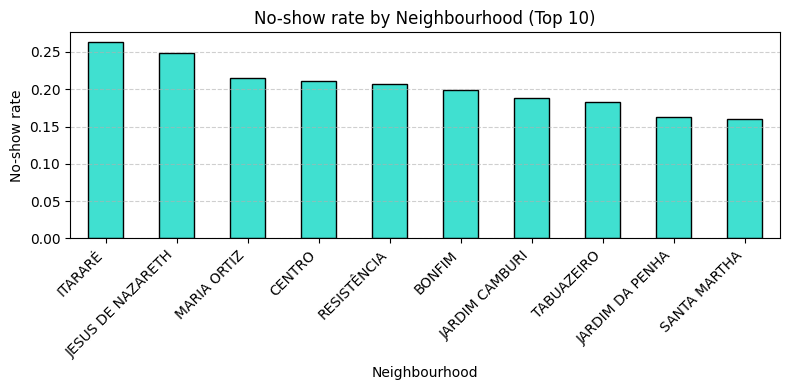

In [27]:
top_neigh = healthcare["Neighbourhood"].value_counts().head(10).index

no_show_neigh = (
    healthcare[healthcare["Neighbourhood"].isin(top_neigh)]
    .groupby("Neighbourhood")["No_show"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))

no_show_neigh.plot(
    kind="bar",
    color="turquoise",
    edgecolor="black"
)

plt.title("No-show rate by Neighbourhood (Top 10)")
plt.xlabel("Neighbourhood")
plt.ylabel("No-show rate")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

The no\-show rate varies across neighborhoods, but remains within a relatively narrow range\. This indicates that geographic location alone is not a dominant predictor, although it may capture subtle contextual differences\. 

Given its high cardinality and long\-tail distribution, this feature will require careful encoding during preprocessing, such as grouping rare categories or using frequency\-based encoding\.

These findings directly inform the preprocessing pipeline\. Numerical variables \(Age and Date\.diff\) will require scaling and robust handling due to skewness, while categorical variables will be processed through imputation and encoding\. In particular, low\-cardinality variables are suitable for one\-hot encoding, whereas Neighborhood requires careful handling due to its high cardinality and sparsity\.

# Preprocessing

The preprocessing phase aims to transform the raw dataset into a format suitable for machine learning while ensuring a fully leakage\-free experimental setup\.

From this point onward, the analysis is carried out on  healthcare\_missing, namely the version of the dataset in which missing values are explicitly preserved\. Missing data is not handled manually at this stage\. Instead, it will be addressed within scikit\-learn preprocessing pipelines, so that all transformations are learned exclusively from the training data and consistently applied to unseen data\. 

### Target Definition

In the original dataset, appointment attendance is represented by the variable Showed\_up\. For clarity and interpretability, the predictive task is reformulated using the derived binary variable No\_show, where:

- O indicates that the patient attended the appointment

- 1 indicates that the patient did not attend the appointment

This choice aligns the target variables with the objective of the project, namely the prediction of missed appointments, and makes the interpretation of model outputs more intuitive, as the positive class directly corresponds to the event of interest\.

As a first preprocessing step,  No\_show is created directly from Showed\_up within healthcare\_missing, so that the target definition remains fully consistent with the dataset used in the subsequent preprocessing and modeling stages\. The original variable Showed\_up is then removed from the feature matrix, since it contains the same information as the target and would otherwise introduce severe data leakage\.

In [28]:
# Create the derived binary target variable directly in healthcare_missing
healthcare_missing["No_show"] = (healthcare_missing["Showed_up"] == False).astype(int)

# Define target
target = "No_show"

# Separate features and target
X = healthcare_missing.drop(columns=[target, "Showed_up"])
y = healthcare_missing[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:\n", y.value_counts(normalize=True))

X shape: (106982, 14)
y shape: (106982,)

Target distribution:
 No_show
0    0.797396
1    0.202604
Name: proportion, dtype: float64


### Data Transformation Pipeline

The following table summarizes the preprocessing strategy for each feature group, providing a clear and structure overview of how different variable types are handled\. This design step ensures consistency between the conceptual preprocessing plan and its implementation within scikit\-learn pipelines\.

<img src="image-20260116-130605.png" width="" align="" />

### Drop ID

Identifier are removed before defining the preprocessing pipelines, as they do not carry predictive information and cannot generalize to unseen data\. Their inclusion could lead the model to learn spurious patterns unrelated to the underlying prediction task

In [29]:
# Drop identifier columns
X = X.drop(columns=["PatientId", "AppointmentID"])

# Confirm updated dimensionality after dropping IDs
print("X shape after dropping IDs:", X.shape)

X shape after dropping IDs: (106982, 12)


## Feature Engineering

Feature engineering introduces additional variables from existing features to better capture patterns relevant to the prediction task\.

### Waiting Time Representations

Wait Bucket: The first engineered representation converts the continuous waiting time into discrete intervals\. This transformation is intended to capture threshold\-like effects, where the probability of no\-show may change more sharply after certain delays rather than increasing smoothly\.

This representation is especially useful when the relationship between waiting time and the target is monotonic, but not linear\.

In [30]:
# 1) Wait bucket: discretized waiting time
X["wait_bucket"] = pd.cut(
    X["Date.diff"],           # original waiting time in days
    bins=[-1, 1, 3, 7, 14, 30, np.inf],   # clinically meaningful delay intervals
    labels=["0_1", "1_3", "3_7", "7_14", "14_30", "30_plus"]
)

print(X[["Date.diff", "wait_bucket"]].head())

   Date.diff wait_bucket
0          0         0_1
1          0         0_1
2          0         0_1
3          0         0_1
4          0         0_1


Interaction \(SMS x waiting time\): The second engineered representation models the interaction between SMS reminders and waiting time\. The objective is to capture whether the effect of an SMS reminder may depend on how long the patient has to wait before the appointment\.

This allows the model to represent non\-additive effects\. For example, reminders may be less effective when the appointment is fair in the future, or conversely more relevant for longer delays\.

In [31]:
# 2) Interaction between SMS reminder and waiting time
X["sms_x_wait"] = X["SMS_received"] * X["Date.diff"]

# Inspect original variables and derived interaction
print(X[["SMS_received", "Date.diff", "sms_x_wait"]].head())

   SMS_received  Date.diff  sms_x_wait
0           0.0          0         0.0
1           0.0          0         0.0
2           0.0          0         0.0
3           0.0          0         0.0
4           NaN          0         NaN


Long waiting time \(binary\): The third engineered representation is a binary indicator identifying appointments with waiting time above 30 days\. This isolates a potential high\-risk regime in which very long delays may substantially increase the probability of no\_show\.

In [32]:
# 3) Binary indicator for long waiting time
X["long_wait"] = (X["Date.diff"] > 30).astype(int)

# Inspect original waiting time and new binary flag
print(X[["Date.diff", "long_wait"]].head())

   Date.diff  long_wait
0          0          0
1          0          0
2          0          0
3          0          0
4          0          0


### Features groups

The next step consists in grouping variables according to their semantic role and preprocessing requirements\. This is a crucial design choice, since variables stored in similar formats may still require different transformations\.

Continuous numerical features are handled separately from binary indicators, because the former require both imputation and scaling, while the latter should preserve their original 0/1 meaning\. Nominal categorical variables require imputation followed by one\-hot encoding, whereas raw datetime variables cannot be used directly and must be transformed into informative calendar\-based features through a custom transformer\.

Although data types can be inspected automatically, the final grouping is defined manually to ensure semantic correctness and full consistency with the preprocessing strategy\.

In [33]:
# IDs 
id_cols = ["PatientId", "AppointmentID"]

# Continuous numerical features
num_cols = ["Age", "Date.diff", "sms_x_wait"]

# Binary / 0-1 indicators 
bin_cols = ["Scholarship", "SMS_received", "Hypertension", "Diabetes", "Alcoholism", "Handcap", "long_wait"]

# Nominal categorical features
cat_cols = ["Gender", "Neighbourhood", "wait_bucket"]

# Datetime raw -> custom transformer 
date_cols = ["ScheduledDay", "AppointmentDay"]


### Custom Tranformer

Based on the preprocessing blueprint defined above, the next step is to translate the design decisions into concrete scikit\-learn components\.

To keep the workflow modular, reproducible and protected against data leakage, preprocessing operations are implemented through Pipeline and ColumnTransformer objects\. This allows different transformations to be applied to different feature groups while ensuring that all preprocessing steps are fitted only on the training data and then consistently applied to validation and test data\.

A custom transformer is needed for the datetime variables, because ScheduledDay and AppointmentDay cannot be used directly by standard machine learning algorithms in their raw format\. The transformer extracts informative calendar\-based features, such as weekday, month, weekend indicators and scheduling hour, converting datetime information into numerical variables that can be used by the model\.

This transformer is stateless: its fit\(\) method does not learn parameters from the data, while transform\(\) method applies the same deterministic feature extraction logic every time\. The transformer pipeline after the train\-test split, keeping the experimental protocol leakage\-free\.

In [34]:
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Custom transformer that extracts calendar-based features from datetime columns.
    """

    def __init__(self, scheduled_col="ScheduledDay", appointment_col="AppointmentDay"):
        self.scheduled_col = scheduled_col      # name of scheduling datetime column
        self.appointment_col = appointment_col  # name of appointment datetime columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_ = X.copy()   # avoid modifying original input

        # COnvert input columns to datetime to ensure robust downstream extraction
        scheduled = pd.to_datetime(X_[self.scheduled_col], errors="coerce")
        appointment = pd.to_datetime(X_[self.appointment_col], errors="coerce")

        # Scheduled day features
        scheduled_weekday = scheduled.dt.dayofweek.to_numpy().reshape(-1, 1)
        scheduled_month = scheduled.dt.month.to_numpy().reshape(-1, 1)
        scheduled_hour = scheduled.dt.hour.to_numpy().reshape(-1, 1)
        scheduled_is_weekend = (scheduled.dt.dayofweek >= 5).astype(int).to_numpy().reshape(-1, 1)

        # Appointment day features
        appointment_weekday = appointment.dt.dayofweek.to_numpy().reshape(-1, 1)
        appointment_month = appointment.dt.month.to_numpy().reshape(-1, 1)
        appointment_is_weekend = (appointment.dt.dayofweek >= 5).astype(int).to_numpy().reshape(-1, 1)

        # COncatenate all extracted features into a single numeric matrix
        out = np.hstack([
            scheduled_weekday,
            scheduled_month,
            scheduled_hour,
            scheduled_is_weekend,
            appointment_weekday,
            appointment_month,
            appointment_is_weekend
        ])

        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([
            "ScheduledDay_weekday",
            "ScheduledDay_month",
            "ScheduledDay_hour",
            "ScheduledDay_is_weekend",
            "AppointmentDay_weekday",
            "AppointmentDay_month",
            "AppointmentDay_is_weekend"
        ])


Once the custom transformer for date time features has been defined, the preprocessing strategy can be fully implemented by grouping variables according to their type and defining a dedicated pipeline for each group\. 

Specifically:

- numerical features are imputed using the median and standardized, 

- binary indicators are imputed, but kept in their original numeric form,

- nominal categorical features are imputed and one\-hot encoded,

- date time features are processed through the custom transformer defined above\.

These pipelines are then combined into a single ColumnTransformer, which represents the complete preprocessing block to be applied consistently to both training and test data\.

### Pipeline 1: Continuous numeric features 

Continuous numerical features are imputed using the median to ensure robustness to skewness and outliers\. Features are then standardized to place them on a common scale, which is important for models sensitive to feature magnitude\.

In [35]:
# Continuous numeric features identified in the inspection phase
num_cols = ["Age", "Date.diff"]

# Pipeline for continuous numeric features:
# 1) Impute missing values with the median (robust to skewness/outliers)
# 2) Standardize to zero mean and unit variance
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Pipeline 2: Binary / 0\-1 indicators

Binary indicator variables are already encoded as 0/1 numerical values and therefore do not require scaling or encoding\. Applying transformations such as standardization would distort their semantic meaning\.

The only required preprocessing step is the imputation of missing values, which is performed using the most frequent value\. This preserves the original distribution of the variable while ensuring compatibility with downstream models\.

In [36]:
# Binary / 0-1 indicators (already numeric): only imputation is needed
bin_cols = ["Scholarship", "SMS_received", "Hypertension", "Diabetes", "Alcoholism", "Handcap"]

binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])


### Pipeline 3: Nominal categorical features

Nominal categorical variables do not possess any intrinsic order and therefore cannot be treated as numerical features\. To convert them into a format suitable for machine learning models, one\-hot encoding is applied\.

Before encoding, missing values are imputed using the most frequent category\. This ensures that the encoder receives complete data while preserving the most representative category distribution\.

The OneHotEncoder is configured with handle\_unkwnon="ignore" to ensure robustness when encountering unseen categories in the test set, preventing runtime errors and improving generalization\.

In [37]:
# Nominal categorical features
cat_cols = ["Gender", "Neighbourhood"]

# Pipeline for nominal categorical features:
# 1) Impute missing values using the most frequent category
# 2) Apply one-hot encoding to convert categories into numeric features
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


### Pipeline 4: Datetime features

Raw datetime variables are first transformed into calendar\-based features using a custom transformer\. The resulting features are then imputed, ensuring consistency and full integration within the preprocessing pipeline\.

In [38]:
# Pipeline for datetime features: custom feature extraction + imputation
date_pipeline = Pipeline(steps=[
    ("date_features", DateFeatureExtractor(
        scheduled_col="ScheduledDay",
        appointment_col="AppointmentDay"
    )),
    ("imputer", SimpleImputer(strategy="most_frequent"))
])


### Column Transformer

All preprocessing steps defined for the different feature groups are combined into a single ColumnTransformer\. This component applies the appropriate transformation pipeline to each subset of features, ensuring that all variables are processed according to their semantic role\.

This design guarantees modularity and consistency, as each transformation is applied only to the relevant features\. Moreover, the entire preprocessing workflow is encapsulated in a single object, which can be seamlessly integrated into a machine learning pipeline\.

The parameter remainder="drop" ensures that only the explicitly defined columns are retained, avoiding unintended propagation of unused variables\. Additionally, setting sparse\_threshold=0\.0 guarantees a dense output matrix, improving compatibility with downstream models\.

In [39]:
# Combine all feature-specific preprocessing pipelines into one object

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),     # continuous numeric features
        ("bin", binary_pipeline, bin_cols),      # binary indicators
        ("cat", categorical_pipeline, cat_cols), # nominal categorical variables
        ("date", date_pipeline, date_cols),      # raw datetime variables
    ],
    remainder="drop",   # discard any columns not explicilty assigned
    sparse_threshold=0.0 # force dense output even with one-hot encoded features
)

# Preview the diagram
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.0
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

### Train Test Split

The dataset is then split into training and test sets, allocating 80% of the observations to the training set and 20% to the test set\. Stratification \(stratify=y\) is applied in order to preserve the original class distribution of the target variable in both subsets\. This is particularly important in this project, as the target variable is imbalanced and the minority class \(No\_show = 1\) represents the event of interest\.

Performing the split at this stage ensures that the test set remains completely unseen during subsequent steps of the modeling pipeline\.

In [40]:
# Split data into train and test sets while preserving class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # reserve 20% of data for final evaluation
    random_state=42, # ensure reproducibility
    stratify=y       # preserve target imbalance in both splits
)

# Verify split dimensions and target balance
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (85585, 15) Test shape: (21397, 15)
Train target distribution:
 No_show
0    0.797394
1    0.202606
Name: proportion, dtype: float64
Test target distribution:
 No_show
0    0.797402
1    0.202598
Name: proportion, dtype: float64


### Sanity check on the preprocessing transformations

The preprocessing pipeline is then fitted exclusively on the training set and subsequently applied to both training and test data\. In particular, fit\_transform\(\) is used on X\_train, while only transform\(\) is applied to X\_test\.

This distinction is crucial: all preprocessing parameters, such as imputation statistics, scaling coefficients, encoded categories and engineered features, are learned only from the training data\. The test set is never used during this learning phase\.

This procedure guarantees a leakage\-free experimental setup and ensures that model evaluation is performed on truly unseen data\.

At this stage, the transformed datasets are generated only for inspection and verification purposes, in order to confirm that the preprocessing pipeline behaves as expected\.

In [41]:
# First preprocessing only on training data, then apply the same transformations to test data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Sanity checks on transformed matrices
print("Data successfully split and transformed.")
print(f"Training set: {X_train_proc.shape}, test set: {X_test_proc.shape}")

Data successfully split and transformed.
Training set: (85585, 98), test set: (21397, 98)


Importantly, the transformed arrays produced at this stage \(X\_train\_proc, X\_test\_proc\) are not used directly for model training\. Instead, the same preprocessing object will later be embedded inside the modeling pipeline, ensuring that preprocessing is re\-fitted within each cross\-validation fold\.

This design choice guarantees a fully correct experimental protocol and prevents any form of data leakage during model selection and evaluation\.

## Modeling pipeline

At this stage, the model is defined not as a single classifier, but as a complete modeling pipeline composed of multiple steps\. This design ensures that all preprocessing, resampling and transformation operations are learned exclusively on the training data within each cross\-validation split, thereby preventing data leakage\. 

Specifically, each candidate model includes four possible components: preprocessing, optioal class rebalancing, optional dimensionality reduction and\. afinal classifier\. By treating the whole workflow as a single object, every transformation is learned only from the training data withing each cross\-validation split\.

### Abstract Modeling pipeline

At this stage, the pipeline is defined in an abstract and modular form, without committing to specific modeling choices\. This allows each component to be systematically activated, bypassed or configured during the model selection phase\.

The pipeline is explicitly structured to include preprocessing, optional resampling, optional dimensionality reduction and classification as separate, configurable steps\. This structure enables systematic model selection through configuration search\.

In [42]:
# Define a full modeling pipeline
model_pipeline = IMBPipeline([
    ('preprocessor', preprocessor),  # full preprocessing block deinfed earlier
    ('sampler', None),               # optional class rebalancing step
    ('dim_reduction', None),         # optional feature space reduction/selection
    ('classifier', LogisticRegression())             # final predictive model
]) 

In [43]:
model_pipeline

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.0
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

This visualization confirms the correct integration of all preprocessing components within the pipeline, ensuring that transformations are applied consistently and in the correct order during training and validation\.

## Configurations

The next step consists in defining the search space explored ruing model selection\. Instead of fixing a single pipeline in advance, the procedure evaluates alternative configurations for class rebalancing, dimensionality reduction and classification\. 

### Sampler Configurations

Class imbalance is addressed through an optional sampling step applied exclusively on the training data within the pipeline\. This ensures that class rebalancing does not introduce information leakage into the validation or test sets\.

Three alternative are evaluated:

- No resampling acts as a baseline and allows the model to learn under the original class distribution\. This is important because in some cases rebalancing may not improve generalization and may instead distort the underlying data structure\.

- The second is SMOTE, an oversampling technique that generates artificial minority class examples by interpolating between nearby minority points\. The intuition is that this may help the model better represent the minority no\_show class without repeating the same records\.

- The third is RandomOverSampler, a simpler strategy that duplicates existing minority examples\. Although naive, it is often useful benchmark because it isolates the effect of pure class balancing without introducing synthetic feature combinations\.

 This comparison allows assessing whether explicit rebalancing improves generalization, especially for the positive \(no\-show\) class\.

In [44]:
sampler_configs = [
    {
        'sampler': [None] # No resampling
        # baseline: keep original class distribution
        }, 
    {
        'sampler': [SMOTE(random_state=42)],
        #synthetic oversampling of minority class

        'sampler__sampling_strategy': [0.5, 1.0, 0.8]
         # test partial vs full balancing of minority / majority ratio
        },
    {'sampler': [RandomOverSampler(random_state=42)],
    # duplicate minority examples instead of generating synthetic ones
      'sampler__sampling_strategy':[0.5, 1.0, 0.8]
      # same comparison of rebalance intensity
      }
]

### Dimensionality reduction configurations

Dimensionality reduction is treated as an optional modeling component rather than a mandatory preprocessing step\. This choice is particularly important in the present project, where the main objective is the prediction of the minority no\-show class and where overly aggressive compression may remove useful signal for rare events\.

Three alternatives are considered:

- The first is no dimensionality reduction, meaning that the full transformed feature space is retained\. This acts as a baseline and allows the search to verify whether reducing dimensionality is actually beneficial\.

- The second is TruncatedSVD\. This is a linear projection method that reduces dimensionality by retaining the main latent directions of variation\. The parameter n\_components controls how many latent dimensions are retained: smaller values produce stronger compression, while larger values preserve more information\.

- The third is SelectKBest with mutual information\. This is not a projection method, but a supervised feature selection approach: instead of compressing all features into a smaller latent space, it retains the top k original features that appear most informative with respect to the target\. Mutual information is especially useful because it can capture non\-linear dependencies between predictors and the target, not just linear associations\. 

This comparison makes it possible to evaluate whether reducing feature space complexity improves predictive performance, computational efficiency and robustness, while preserving sufficient information for minority class detection\.

Moreover, dimensionality reduction methods are treated as interchangeable pipeline components and are jointly evaluated with samplers and classifiers in order to assess their interaction effects within the full model selection procedure\.

In [45]:
# Candidate dimensionality reduction /feature selection strategies
dim_reduction_configs = [
    {
        'dim_reduction': [None]
        # baseline: keep full transofrmed feature space
    },

    {
        'dim_reduction': [TruncatedSVD(random_state=42)],
        # linear latent projection suited to high-dimensional trasnformed data
    'dim_reduction__n_components': [10, 15, 20]
     # number of retained latent diemnsions
    },
    {
        "dim_reduction": [SelectKBest (score_func=mutual_info_classif)],
        # supervised feature selection based on target relevance
        "dim_reduction__k": [20, 40]
        # number of top-ranked features to retain
    }
]

### Classifier configurations

Classifiers are selected to cover different assumptions on the decision boundary, model complexity and interpretability, in order to systematically compare linear, non\-linear and ensemble\-based approaches under the same preprocessing and evaluation pipeline\. 

Logistic Regression is included as the main linear baseline\. It is simple, interpretable and provides well\-calibrated probabilistic outputs\. In addition, regularization can control complexity and reduce overfitting\. The parameter C controls the strength of regularization: smaller values imply stronger regularization, while larger values allow more flexible fitting\. The penalty type \(l1 or l2\) controls the form of shrinkage, with l1 also encouraging sparsity\. The class\_weight parameter allows the classifier to place more emphasis on the minority class directly at the algorithm level\.

Random Forest is included as a bagging\-based ensemble of decision trees\. Its main strength is the ability to model non\-linear interactions and heterogeneous decision patterns without strong distributional assumptions\. The number of trees \(n\_estimators\) controls the size of the ensemble; more trees usually improve stability at a higher computational cost\. max\_depth limits how deep each tree can grow and therefore acts as a complexity control\. min\_samples\_split regulates how easily a node can be split, reducing overfitting if set to larger values\. Again, class\_weight is used to test whether algorithm\-level imbalance handling improves minority\-class detection\.

XGBoost is included as a boosting\-based ensemble\. Unlike Random Forest, which averages many independent trees, XGBoost builds trees sequentially, each one trying to correct the errors of the previous ones\. This often makes it more powerful, but also more sensitive to hyperparameter choices\. The number of trees \(n\_estimators\) controls the size of the boosting sequence, while learning\_rate determines how much tree contributes\. max\_depth controls tree complexity, while subsample injects stochasticity by training each tree on only a fraction of the data\. Finally, scale\_pos\_weight is included because it is the standard XGBoost parameter for handling class imbalance directly at the algorithm level by giving more weight to minority class errors\.

Overall, these three classifiers form a balanced comparison between a linear model, a bagging ensemble and a boosting ensemble\. This is useful because it allows the model selection procedure to test whether the no\_show task is better captured by linear separation, non\-linear averaging or sequential bias correction\.

In [46]:
classifier_configs = [

    # Logistic Regression (linear baseline + regularization)
    {
    "classifier": [LogisticRegression(solver="saga", max_iter=3000, n_jobs=1)],
    "classifier__C": loguniform(1e-3, 1e2),
    "classifier__penalty": ["l1", "l2"],
    "classifier__class_weight": [None, "balanced"]
},

    # Random Forest (bagging ensemble of trees)
   {
    "classifier": [RandomForestClassifier(random_state=42, n_jobs=1)],
    "classifier__n_estimators": [100, 200, 400],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 10],
    "classifier__class_weight": [None, "balanced"]
},

    # XGBoost (boosting ensemble)
    {
    "classifier": [XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        objective="binary:logistic",
        n_jobs=1
    )],
    "classifier__n_estimators": [200, 400],
    "classifier__learning_rate": [0.03, 0.1],
    "classifier__max_depth": [3, 5],
    "classifier__subsample": [0.8, 1.0],
    "classifier__scale_pos_weight": [1.0, 3.0, 4.0]
}
]


Although SVMs are powerful classifiers, they were not selected due to their sensitivity to hyper parameter tuning and computational cost in the presence of high\-dimensional, sparse feature representations\.

### Cartesian product of configurations

Instead of fixing a single machine learning pipeline a priori, the model selection process is formulated as a search over a structured configuration space\. This space is obtained by combining three independent design choices: the sampling strategy used to address class imbalance, the dimensionality reduction technique and the classification algorithm together with its hyperparameters\. 

To systematically explore all these alternatives, the Cartesian product of the individual configuration sets is constructed\. Each element of this Cartesian product represents a complete and valid pipeline configuration, defined by a specific sampler, an optional dimensionality reduction step, and a classifier with its hyperparameters\. 

This is implemented iterating over the Cartesian product of the lists sampler\_configs, dim\_reduction\_configs, and classifier\_configs\.

For each combination, the corresponding dictionaries are merged into a single dictionary, which can be directly passed to scikit\-learn's model selection utilities\. The resulting list, all\_configs, therefore defines the entire model selection search space\.

In [47]:
all_configs = [
    dict(itertools.chain(*(d.items() for d in configuration)))
    for configuration in itertools.product(sampler_configs, dim_reduction_configs, classifier_configs)
]



In [48]:
print("Total number of configurations:", len(all_configs))
all_configs[:2]

Total number of configurations: 27


[{'sampler': [None],
  'dim_reduction': [None],
  'classifier': [LogisticRegression(max_iter=3000, n_jobs=1, solver='saga')],
  'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f732d48cb50>,
  'classifier__penalty': ['l1', 'l2'],
  'classifier__class_weight': [None, 'balanced']},
 {'sampler': [None],
  'dim_reduction': [None],
  'classifier': [RandomForestClassifier(n_jobs=1, random_state=42)],
  'classifier__n_estimators': [100, 200, 400],
  'classifier__max_depth': [None, 5, 10],
  'classifier__min_samples_split': [2, 10],
  'classifier__class_weight': [None, 'balanced']}]

After constructing the Cartesian product, the total number of possible configurations is computed using len\(all\_configs\)\. This value provides an explicit measure of the size of the search space and highlights the combinatorial nature of the model selection problem\. In this case, the search space contains 27 distinct pipeline configurations\.

To make the structure of the search space more concrete, the first two elements of all\_configs are displayed\. Each element corresponds to a full pipeline configuration and shows how different modeling choices are encoded in practice\. 

This inspection step is purely exploratory and does not perform any training\. Its purpose is to verify that the Cartesian product has been constructed correctly and that each configuration is compatible with the pipeline definition used in the subsequent model selection phase\.

# Models Selection with Nested\-Cross Validation

After defining the preprocessing workflow and the full set of admissible modeling configurations, the next step is to identify the most suitable pipeline for the no\-show prediction task\. In this project, model selection does not concern only the final classifier, but the entire modeling strategy: the possible use of a sampling method, the possible use of dimensionality reduction, the classifier family and the associated hyperparameters\.

To avoid overly optimistic estimates, model selection is carried out through nested cross validation\. This procedure separates the search for the best configuration from the estimation of its generalization performance\. The inner loop is responsible for selecting the best pipeline within each training partition, while the outer loop evaluates that selected pipeline on unseen validation data\.

This distinction is especially important here because the dataset is imbalanced and the class of interest is the minority No\_show class\. Since missed appointments were then encoded as 1, the selection procedure is guided by the F1\-score of the positive class, so that the search focuses on configurations able to balance the identification of no\-shows with the control of false alarms\.

### CV strategies and scoring method

Both cross validation loops are defined through StratifiedKFold, using three folds, shuffling and a fixed random state to make the procedure reproducible\.

Stratification preserves approximately the same proportion of attended and missed appointments in every fold\. This is particularly relevant in an imbalanced classification problem, since strongly unbalanced folds could make both model selection and performance estimates less stable\.

In [49]:
# CV strategies (stratified)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

The scoring function is explicitly defined as the F1\-score computed with pos\_label=1, consistently with the target encoding adopted earlier in the project\. In this way, the optimization focuses specifically on the No\_show class rather than treating both labels symmetrically\.

Accuracy is not used as the model selection criterion because it would be misleading in this context\. Since the majority of patients attend their appointments, a model could obtain a high accuracy while still being ineffective at detecting the minority no\-show cases\.

In [50]:
# No_show is encoded as 1, while attended appointments are encoded as 0

f1_noshow = make_scorer(f1_score, pos_label=1)

### Inner loop: Hyperparameter Optimization

The inner loop performs the actual model selection step within each outer training fold\. Its purpose is to identify the pipeline configuration that achieves the best cross\-validated F1 score on the minority No\_show class, using only the data available in that fold\.

The RandomizedSearchCV object is applied to the full machine learning pipeline, rather than to a classifier in isolation\. Therefore, the search evaluates complete configurations that include preprocessing, sampling strategy, dimensionality reduction and final classifier\. This keeps the comparison methodologically correct, because every transformation is learned only from the training portion of each split, preventing information leakage from validation data\.

The admissible configurations are supplied through all\_configs, which was previously constructed by combining the alternative modeling choices considered in the project\. The search budget is limited to a maximum of 50 sampled configurations, allowing a broad exploration of the candidate space while keeping the computational cost manageable\.

A stratified 3\-fold\-cross\-validation scheme is used in the inner loop\. For every sampled configuration, performance is estimated on the inner validation folds using the no\-show F1\-score\. The best configuration is then refitted on the corresponding outer training data before being evaluated by the outer loop\.

In [51]:
# Inner loop (hyperparameter optimization inside each outer fold)
inner_search = RandomizedSearchCV(
    estimator=model_pipeline,                      # Full pipeline to optimize: 
                                                   # preprocessing -> sampler -> dim_reduction -> classifier

    param_distributions=all_configs,               # Search space defined as the Cartesian product of all possible configurations
    n_iter = min(len(all_configs) * 3, 50),        # Number of randomly sampled configurations 
    cv=inner_cv,                                   # Stratified 3-fold cross validation for the inner loop, used to estimate the perfromance of each configuration
    scoring=f1_noshow,                             # F1 score is used as the optimization metric to handle class imbalance
    n_jobs=1,                                      # Avoid nested parallelism (outer loop is parallelized)
    verbose=1,                                     # Print progress information during the search
    random_state=42,                               # Ensure reproducibility of the random sampling
    error_score='raise',                           # Raise errors if an invalid configuration is encountered
    refit=True
)

### Outer loop: Model Evaluation

The outer loop estimates the generalization performance of the entire model selection procedure\. For each outer fold, the inner randomized search is repeated independently on the outer training split and the resulting best pipeline is evaluated on the corresponding held\-out outer validation split\.

This design ensures that the data used to assess performance are never involved in hyperparameter tuning or pipeline selection\. As a result, the outer scores provide a reliable estimate of how the selection strategy is expected to perform on unseen data\.

The same minority class F1\-score is used in the outer loop, maintaining full consistency between the criterion used to select the model and the criterion used to estimate its performance\.

The outer evaluation also stores the fitted search objects returned by each fold\. This makes it possible to inspect the pipeline selected in every outer iteration and verify whether the search converges toward a stable modeling solution\.

In [52]:
# Outer loop
scores = cross_validate(
    estimator=inner_search,   # RandomizedSearchCV object (inner loop)
    X=X_train,
    y=y_train,
    scoring=f1_noshow,              # Evaluation metric
    cv=outer_cv,                      # 3-fold cross-validation for the outer loop
    return_estimator=True,     # Store the best estimator for each outer fold
    n_jobs=-1,
    verbose=3,
    error_score='raise'
)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END ......................................., score=0.453 total time=41.9min
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END ......................................., score=0.445 total time=45.2min
[CV] END ......................................., score=0.450 total time=41.5min
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed: 83.4min finished


The nested cross validation procedure returns one F1\-score for each outer validation fold, together with their mean and standard deviation\.

In [53]:
print("Nested CV F1 scores:", scores["test_score"])
print("Mean F1:", scores["test_score"].mean())
print("Std F1:", scores["test_score"].std())

Nested CV F1 scores: [0.44480864 0.45268678 0.45005752]
Mean F1: 0.4491843095118619
Std F1: 0.003274968624565838


The resulting scores are very close to one another, with a mean F1\-score of approximately 0\.449 and a vary small standard deviation\. This limited variability suggests that the model selection process is stable across different stratified train\-validation partitions and is not strongly driven by a particular split of the training data\.

These values should be interpreted as an estimate of the expected performance of the model selection procedure, rather than as the final performance of the final model\. The held\-out test set has not been used at this stage and remains reserved for the final evaluation\.

The next step is therefore to inspect which pipeline structures were selected across the outer folds and determine whether the same modeling choices emerge consistently\.

### Inspection of selected pipelines across outer folds

After estimating generalization performance, the best pipeline selected in each outer fold is inspected\. This step is not meant to re\-evaluate the model, but to assess the stability process and understand which modeling configuration is repeatedly preferred\.

The stored estimators returned by the outer cross\-validation allow the selected pipeline of each fold to be examined in terms of sampler, dimensionality reduction step, classifier and classifier hyperparameters\. This provides a direct view of whether the nested search identifies the same structure across different partitions of the data\.

Since the outer\-fold\-F1 score is printed together with each selected pipeline, the structure chosen in each fold can also be interpreted alongside its corresponding validation performance\.

In [54]:
# Inspection of the best pipeline selected in each outer fold
for i, search in enumerate(scores["estimator"], start=1):
    best_pipe = search.best_estimator_

    preproc = best_pipe.get_params()["preprocessor"]
    sampler = best_pipe.get_params()["sampler"]
    dimred = best_pipe.get_params()["dim_reduction"]
    clf = best_pipe.get_params()["classifier"]

    print(f"OUTER FOLD {i}")
    print("sampler:", sampler)
    print("dim_reduction:", dimred)
    print("classifier:", clf)
    print("classifier params:", clf.get_params())
    print("outer test f1:", scores["test_score"][i-1])
    print("-" * 50)

OUTER FOLD 1
sampler: None
dim_reduction: None
classifier: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=1,
              num_parallel_tree=None, ...)
classifier params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsam

The nested cross\-validation procedure consistently selected the same pipeline structure across all outer folds\. In every case, the preferred configuration icnludes the previously preprocessing workflow, no additional resampling step, no dimensionality reduction step and an XGBClassifier as the final estimator\.

This result indicates that, within the explored search space, the model benefits from preserving the complete transformed feature representation and relying on the classifier to learn the relevant decision structure, rather than introducing synthetic oversampling or compressing the feature space\.

The consistency of this choice across folds is important\. It suggests that the selected pipeline is not an unstable consequence of a specific partition of the data, but a robust modeling solution identified repeatedly under different outer training\-validation splits\.

The F1\-scores reported for the outer folds quantify the ability of these selected pipelines to identify No\_show appointments on unseen validation data during the nested evaluation process\.

### Sanity Check: Full Refit of Outer Fold Candidates

After inspecting the pipeline structures selected across the outer folds, the corresponding candidate models are compared through an additional stability check\. Each best estimator returned by nested cross\-validation is cloned, retained on the full training set and evaluated on both training and held\-out test data\.

This step helps verify whether the fold\-specific candidates behave consistently once they are trained on all available development data\. It also provides a preliminary train versus test comparison before selecting one representative candidate for the refinement phase\.

In [55]:
# Sanity check: refit each outer-fold best candidate on the full training set
candidate_train_f1 = []                                    # store training F1 for each candidate
candidate_test_f1 = []                                     # store test F1 for each candidate

print("Sanity check: full-train refit of outer-fold selected candidates")

for i, search in enumerate(scores["estimator"], start=1):
    candidate_model = clone(search.best_estimator_)        # fresh copy of the fold-specific best pipeline
    candidate_model.fit(X_train, y_train)                  # refit on the full training set

    pred_train = candidate_model.predict(X_train)          # training predictions
    pred_test = candidate_model.predict(X_test)            # held-out test predictions

    f1_train_candidate = f1_score(
        y_train, pred_train, pos_label=1
    )                                                       # F1 on minority No_show class, training set

    f1_test_candidate = f1_score(
        y_test, pred_test, pos_label=1
    )                                                       # F1 on minority No_show class, test set

    candidate_train_f1.append(f1_train_candidate)          # save training F1
    candidate_test_f1.append(f1_test_candidate)            # save test F1

    print(
        f"Candidate {i}: "
        f"F1_train={f1_train_candidate:.4f} | "
        f"F1_test={f1_test_candidate:.4f}"
    )                                                       # compare candidate behaviour after full refit

Sanity check: full-train refit of outer-fold selected candidates
Candidate 1: F1_train=0.4677 | F1_test=0.4495
Candidate 2: F1_train=0.4677 | F1_test=0.4495
Candidate 3: F1_train=0.4677 | F1_test=0.4495


The three candidates show essentially identical behavior after full training, with a training F1\-score of approximately 0\.468 and\. atest F1\-score of approximately 0\.450\. The limited gap between training and test performance suggests that the selected XGBoost based configurations generalize reasonably and do not exhibit severe overfitting\.

The very similar results across candidates are also consistent with the previous outer\-fold inspection: nested cross\-validation repeatedly identified the same overall modeling structure and the remaining fold\-specific differences in hyperparamters have only a marginal effect on final performance\.

### Selection of the Candidate Pipeline for Refinement

A single candidate pipeline is selected as the starting for the refinement phase\. To preserve the logic of nested model selection, the representative candidate is chosen according to the best outer\-fold F1\-score returned by nested cross validation, rather than according to the descriptive test\-set sanity check above\.

This choice keeps the held\-out test set from driving the selection decision\. At the same time, since all outer folds converged toward the same structural solution, i\.e\. preprocessing pipeline, no resampling, no dimensionality reduction and an XGBoost classifier, the selected candidate acts as a representative instance of the modeling strategy identified by the nested procedure\.

The estimator is cloned to create a fresh unifitted pipeline with the same selected structure and hyperparameters, ready for the following refinement stage\.

In [56]:
# Select the representative candidate using the best OUTER nested-CV F1-score
best_outer_idx = int(np.argmax(scores["test_score"]))      # index of the strongest outer-fold result

selected_outer_search = scores["estimator"][best_outer_idx] # fitted search object from the selected outer fold
selected_model = selected_outer_search.best_estimator_       # corresponding best pipeline

print("Selected candidate for refinement:")
print(f"Outer fold: {best_outer_idx + 1}")                   # selected outer fold
print(f"Nested-CV outer F1: {scores['test_score'][best_outer_idx]:.4f}")  # unbiased outer-fold F1

selected_model                                             # display selected pipeline structure

Selected candidate for refinement:
Outer fold: 2
Nested-CV outer F1: 0.4527


,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.0
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

The selected candidate comes from the second outer fold, which achieved the highest nested CV validation F1\-score\. Its structure matches the configuration repeatedly selected across folds, confirming that the candidate chosen for refinement is consistent with the overall model selection outcome\.

### Definition of the Candidate Pipeline for Refinement

After selecting a representative candidate from the nested cross\-validation stage, a clean pipeline is defined for the refinement phase\. At this point, the broad comparison among classifiers, sampling strategies and dimensionality reduction methods has already been completed\.

The pipeline is reconstructed according to the structure repeatedly preferred across outer folds: the previously defined preprocessing workflow, no resampling step, no dimensionality reduction step and an XGBClassifier as final estimator\. This creates a fixed modeling architecture on which a more focused local hyperparameter search can be performed\.

In [57]:
# Fixed pipeline structure selected during nested cross-validation
candidate_pipeline = IMBPipeline([
    ("preprocessor", preprocessor),                        # same preprocessing workflow selected earlier
    ("sampler", None),                                     # no resampling step selected
    ("dim_reduction", None),                               # no dimensionality reduction selected
    ("classifier", XGBClassifier(
        random_state=42,                                   # reproducibility
        use_label_encoder=False,                           # avoid deprecated label encoder behaviour
        eval_metric="logloss"                              # stable binary classification metric inside XGBoost
    ))
])

## Refinement of the Selected Model

After identifying a single candidate model through nested\-cross validation, the refinement phase focuses on improving the model's generalization performance without altering its overall architecture\.

In this step, the structure of the pipeline remains fixed, and only a restricted set of classifier hyperparameters is further optimized in a local region around the values selected during model selection\. This keeps the refinement computationally efficient while preserving methodological consistency\.

Since the selected candidate does not include a resampling step, the refinement search space must remain coherent with that structure\. Therefore, no sampler\-related parameters are tuned at this stage\.

In [58]:
# Local refinement search space around the selected XGBoost configuration
refinement_params = {
    "classifier__n_estimators": randint(200, 600),         # number of boosting trees
    "classifier__max_depth": randint(3, 8),                # tree complexity
    "classifier__learning_rate": uniform(0.01, 0.1),       # contribution of each new tree
    "classifier__subsample": uniform(0.6, 0.4),            # row sampling for regularization
    "classifier__colsample_bytree": uniform(0.6, 0.4),     # feature sampling for regularization
    "classifier__gamma": uniform(0, 5),                    # minimum gain required for a split
    "classifier__min_child_weight": randint(1, 6),         # minimum child node weight
    "classifier__scale_pos_weight": uniform(3, 5)          # imbalance handling inside XGBoost
}

# Cross-validation for refinement, not nested because the model family is already selected
cv_refine = StratifiedKFold(
    n_splits=3,                                             # 3-fold stratified CV
    shuffle=True,                                          # randomized fold assignment
    random_state=42                                        # reproducibility
)

rs_refine = RandomizedSearchCV(
    estimator=candidate_pipeline,                          # fixed selected pipeline
    param_distributions=refinement_params,                 # local XGBoost search space
    n_iter=20,                                             # number of sampled configurations
    scoring=f1_noshow,                                     # optimize F1 on No_show = 1
    cv=cv_refine,                                          # stratified CV for refinement
    n_jobs=1,                                              # stable execution
    random_state=42,                                       # reproducible random search
    verbose=1,                                             # show search progress
    error_score="raise",                                   # expose invalid configurations immediately
    refit=True                                             # refit best configuration on full training set
)

rs_refine.fit(X_train, y_train)     

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': <scipy.stats....x7f732e656d90>, 'classifier__gamma': <scipy.stats....x7f732e654e50>, 'classifier__learning_rate': <scipy.stats....x7f732e657290>, 'classifier__max_depth': <scipy.stats....x7f732e656410>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` s

The refinement phase is performed only on the training set, so the held\-out test set remains untouched\. This preserves the integrity of final evaluation while allowing a more fine\-grained optimization of the already selected model family\.

### Best estimator after refinement

After the local search, the best refined estimator can be inspected to verify the final selected structure\.

In [59]:
# Best estimator after local refinement
final_model = rs_refine.best_estimator_                     # refined pipeline already refitted on full training set

print("Best CV F1 during refinement:", rs_refine.best_score_)  # best mean CV F1 obtained in refinement
print("Best params:", rs_refine.best_params_)                  # selected XGBoost hyperparameters

Best CV F1 during refinement: 0.4487731184851609
Best params: {'classifier__colsample_bytree': np.float64(0.6161734358153725), 'classifier__gamma': np.float64(3.553314448428937), 'classifier__learning_rate': np.float64(0.02108908208118313), 'classifier__max_depth': 6, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 378, 'classifier__scale_pos_weight': np.float64(3.157145928433671), 'classifier__subsample': np.float64(0.8545641645055122)}


The best cross\-validation F1\-score obtained during refinement is approximately 0\.449\. This value is very close to the nested cross\-validation estimates obtained before refinement, suggesting that the local hyperparameter search improves the model only marginally rather than radically changing its behaviour\.

This is expected because the refinement phase does not compare completely different model families\. It only fine tunes the selected XGBoost configuration within a limited hyperparameter region\.

### Training vs test sanity check after refinement

The refined model is then evaluated on both the training set and the held\-out test set as a final sanity check\. This comparison is not used to select the model, but to verify whether the refined estimator shows signs of overfitting before moving to the complete evaluation\.

Both scores are computed using the F1\-score for the positive class, where No\_show = 1\.

In [60]:
# Training vs test sanity check after refinement
y_pred_train = final_model.predict(X_train)                 # predictions on training data
y_pred_test = final_model.predict(X_test)                   # predictions on held-out test data

f1_train_refined = f1_score(
    y_train, y_pred_train, pos_label=1
)                                                           # refined F1 on the No_show class, training set

f1_test_refined = f1_score(
    y_test, y_pred_test, pos_label=1
)                                                           # refined F1 on the No_show class, test set

print("Training F1 after refinement:", f1_train_refined)   # inspect fitted performance
print("Test F1 after refinement:", f1_test_refined)        # inspect generalization before full evaluation



Training F1 after refinement: 0.4727461755532452
Test F1 after refinement: 0.44819919964428634


After refinement, the training F1\-score is approximately 0\.473, while the held\-out test f1\-score is approximately 0\.448\. The difference between the two values is limited, which suggests that the refined model does not strongly overfit the training data\.

At the same time, the test F1\-score remains very close to the performance observed before refinement\. This indicates that the refinement phase produced a stable final estimator, but did not substantially change the predictive limits of the selected model\.

# Evaluation

The final evaluation is performed on the held\-out test set, after model selection through nested cross\-validation and local refinement on the training data\.  

Since the dataset is strongly imbalanced, the analysis focuses on metrics that are informative for the minority No\_show class rather than relying on accuracy alone\. The positive class remains consistently defined as No\_show = 1, in line with the project objective of identifying patients who are more likely to miss their appointment\. 

The following analyses evaluate complementary aspects of the final model: predicted risk scores, class discrimination, threshold dependent trade\-offs, prediction errors and model interpretability\.

### Predicted No Show Probability Scores

Before converting the model output into binary predictions, the final refined model produces a predicted probability for each patient\. Here, this score represents the estimated risk of missing the appointment, with No\_show = 1 as the positive class\.

In [79]:
# Predicted probability of the positive class No_show = 1
y_scores = final_model.predict_proba(X_test)[:, 1]

# Summary statistics of the predicted risk scores
pd.Series(y_scores).describe()

count    21397.000000
mean         0.399428
std          0.215453
min          0.027929
25%          0.135225
50%          0.464026
75%          0.577126
max          0.814932
dtype: float64

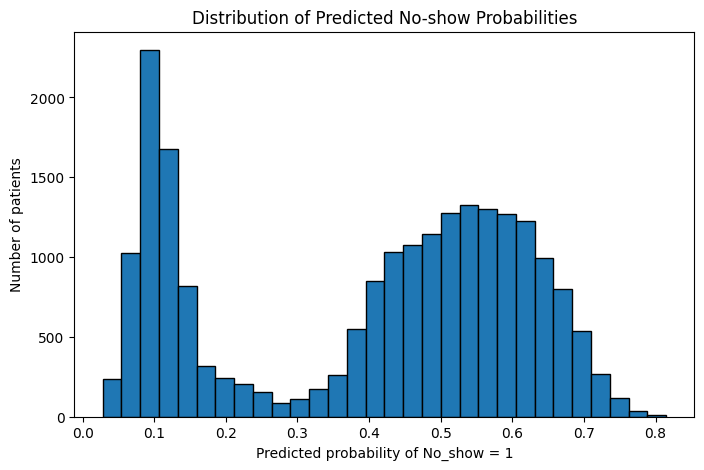

In [81]:
plt.figure(figsize=(8, 5))
plt.hist(y_scores, bins=30, edgecolor="black")
plt.xlabel("Predicted probability of No_show = 1")
plt.ylabel("Number of patients")
plt.title("Distribution of Predicted No-show Probabilities")
plt.show()

The summary statistics and histogram show that many patients receive intermediate probability scores, with an average around 0\.40 and a median around 0\.46\. The distribution also suggests two main risk regions: a low risk group around 0\.08\-0\.15 and a medium to high risk group around 0\.45\-0\.65\.

This supports the need for threshold based evaluation\. Since many scores are close to the central range, changing the decision threshold can strongly affect how many patients are classified as no\-shows\. For this reason, precision\-recall analysis and threshold tuning are used to choose a more suitable operating point than the default 0\.5 threshold\.

### Learning Curve Analysis

The Learning curve evaluates how the model's performance evolves as the size of the training data increases\. 

By comparing training and cross\-validation performance, the curve helps assess whether the model suffers from overfitting \(high variance\) or underfitting \(high bias\) and whether additional data would improve generalization\.

In this project, the curve is computed using the F1\-score on the minority no\-show class, so that both the training and validation trajectories remain aligned with the real optimization objective\.

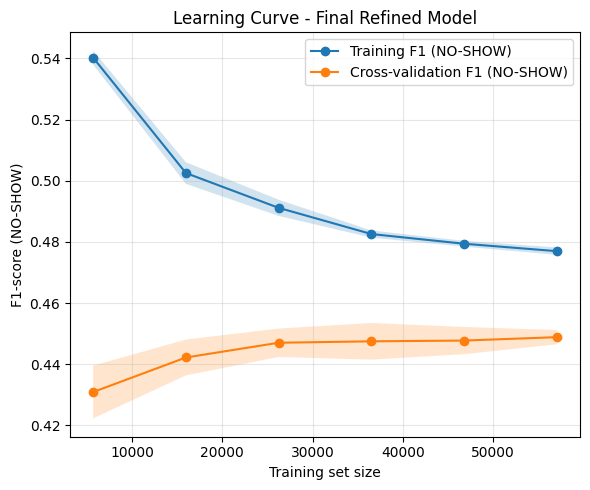

In [63]:
# Final refined model
final_model = rs_refine.best_estimator_                              # refined pipeline selected after local search

# Stratified CV consistent with the rest of the project
cv_learning = StratifiedKFold(
    n_splits=3,                                                       # preserve class distribution across folds
    shuffle=True,                                                    # randomize fold assignment
    random_state=42                                                  # ensure reproducibility
)

# Compute learning curve using F1 on the NO-SHOW class (label = 1)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=final_model,                                           # final full pipeline
    X=X_train,                                                        # training features only
    y=y_train,                                                        # training target only
    cv=cv_learning,                                                   # stratified cross-validation
    scoring=f1_noshow,                                                # minority-class F1 score
    train_sizes=np.linspace(0.1, 1.0, 6),                            # increasing fractions of training data
    n_jobs=-1                                                         # parallel computation
)

# Mean and standard deviation across folds
train_mean = np.mean(train_scores, axis=1)                           # average training F1
train_std = np.std(train_scores, axis=1)                             # variability of training F1

val_mean = np.mean(val_scores, axis=1)                               # average validation F1
val_std = np.std(val_scores, axis=1)                                 # variability of validation F1

# Plot learning curve
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Training F1 (NO-SHOW)")          # training trajectory
plt.plot(train_sizes, val_mean, 'o-', label="Cross-validation F1 (NO-SHOW)")   # validation trajectory

# Add uncertainty bands across folds
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2                                                        # training-score variability
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2                                                        # validation-score variability
)

plt.xlabel("Training set size")
plt.ylabel("F1-score (NO-SHOW)")
plt.title("Learning Curve - Final Refined Model")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


The training F1\-sore decreases as the training set grows, while the validation F1\-score increases and then stabilizes around 0\.45\.

This suggests that the model benefits from more data at the beginning, but then reaches a plateau\. A gap between training and validation performance remains, indicating some variance, but not severe overfitting,

Overall, the learning curve suggests that the task is intrinsically difficult, mainly because of class imbalance and overlap between show and no\-show patients\.

### ROC Curve

The ROC Curve evaluates the model's ability to discriminate between two classes across all possible decision thresholds\.

It plots the True Positive Rate \(Recall\) against the False Positive rate, providing a threshold\-independent view of performance\. The ROC AUC summarizes this behavior into a single value\.

It is useful as a general discrimination measure, but it is not the main evaluation tool here, because ROC curves can be less informative in imbalanced settings\.

ROC AUC (NO-SHOW): 0.740410223816336


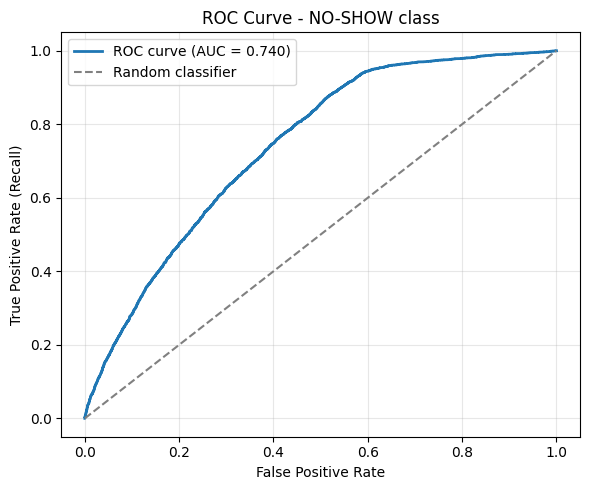

In [64]:
# Predicted probabilities for the NO-SHOW class
y_scores = final_model.predict_proba(X_test)[:, 1]                  # probability assigned to No_show = 1

# ROC computation
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_scores,
    pos_label=1                                                      # positive class: missed appointment
)
roc_auc = roc_auc_score(y_test, y_scores)                            # threshold-independent discrimination score

print("ROC AUC (NO-SHOW):", roc_auc)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")  # model ROC curve
plt.plot([0, 1], [0, 1], linestyle="--", color="gray",
         label="Random classifier")                                 # no-skill reference line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - NO-SHOW class")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The ROC AUC of approximately 0\.74 indicates that the model has a reasonable ability to distinguish between no\-show and show patients\. 

However, in highly imbalanced settings, ROC curves can be overly optimistic, since they do not reflect the actual proportion of positive examples\. For this reason, ROC analysis is complemented with Precision\-Recall evaluation, which is more informative for the minority class\.

### Precision Recall Curve

The Precision Recall curve focuses on the performance of the model on the positive class \(No\_show = 1\)\.

It plots precision against recall for different thresholds, making it particularly suitable for imbalanced datasets where the minority class is of primary interest\.

Average Precision (NO-SHOW): 0.3850533228341403


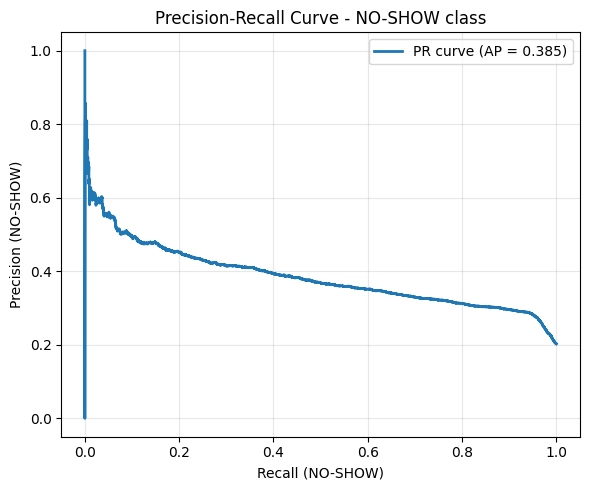

In [65]:
# PR computation
precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_scores,
    pos_label=1                                                      # focus on the No_show class
)

ap = average_precision_score(y_test, y_scores)                      # area-like summary of PR performance

print("Average Precision (NO-SHOW):", ap)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(
    recall,
    precision,
    lw=2,
    label=f"PR curve (AP = {ap:.3f})"                                # average precision in legend
)

plt.xlabel("Recall (NO-SHOW)")
plt.ylabel("Precision (NO-SHOW)")
plt.title("Precision-Recall Curve - NO-SHOW class")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The curve shows that precision decreases steadily as recall increases, highighting the trade\-off between identifying more no\-show patients and maintaining prediction reliability\.

The Average Precision \(AP=0\.38\) refelcts moderate performance: the model captures some useful signal, but struggles to maintain high precision when recall increases\.

This behavior is expected given the class imbalance and overlapping feature distributions between the two classes, in addition detecting more no\-show patients also increases the number of false alarms\.

### Threshold Analysis

The threshold analysis explores how precision, recall and F1\-score change as the decision threshold varies\.

Instead of relying on the default threshold of 0\.5, this analysis identifies the threshold that optimizes the F1\-score for the No\-show class, balancing precision and recall\.

Best threshold (max F1): 0.47
Precision at best threshold: 0.319
Recall at best threshold: 0.770
F1 at best threshold: 0.451


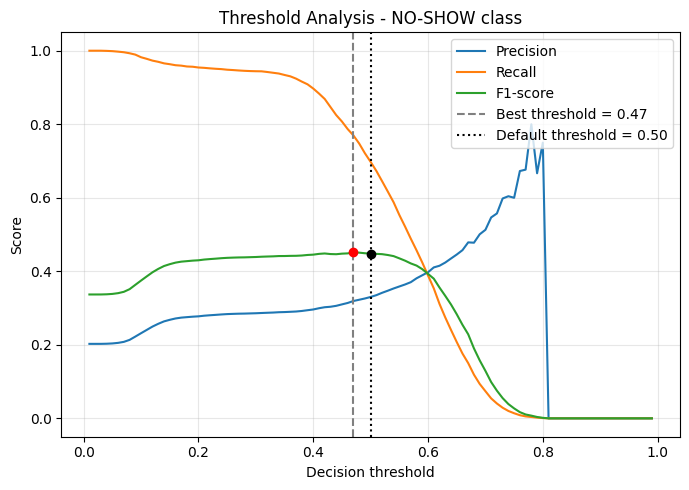

In [66]:
# Predicted probabilities for the positive class: NO-SHOW = 1
y_scores = final_model.predict_proba(X_test)[:, 1]                  # probabilities used to vary the decision rule

thresholds = np.linspace(0.01, 0.99, 99)                            # candidate classification thresholds

precision_list = []                                                  # precision at each threshold
recall_list = []                                                     # recall at each threshold
f1_list = []                                                         # F1-score at each threshold

# Evaluate metrics at each threshold
for thr in thresholds:
    y_pred_thr = (y_scores >= thr).astype(int)                      # convert probabilities into class labels

    precision_list.append(
        precision_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    )                                                                # precision for No_show = 1

    recall_list.append(
        recall_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    )                                                                # recall for No_show = 1

    f1_list.append(
        f1_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    )                                                                # F1 balancing precision and recall

# Convert lists to arrays
precision_arr = np.array(precision_list)                            # precision values across thresholds
recall_arr = np.array(recall_list)                                  # recall values across thresholds
f1_arr = np.array(f1_list)                                          # F1 values across thresholds

# Select threshold maximizing F1
best_idx = np.argmax(f1_arr)                                        # index of the highest F1-score
best_threshold = thresholds[best_idx]                               # threshold associated with max F1
best_precision = precision_arr[best_idx]                            # precision at selected threshold
best_recall = recall_arr[best_idx]                                  # recall at selected threshold
best_f1 = f1_arr[best_idx]                                          # maximum F1-score

# Default threshold for comparison
default_idx = np.argmin(np.abs(thresholds - 0.5))                   # threshold closest to 0.50
default_f1 = f1_arr[default_idx]                                    # F1 at default decision threshold

print(f"Best threshold (max F1): {best_threshold:.2f}")
print(f"Precision at best threshold: {best_precision:.3f}")
print(f"Recall at best threshold: {best_recall:.3f}")
print(f"F1 at best threshold: {best_f1:.3f}")

# Plot threshold-dependent metrics
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision_arr, label="Precision")              # precision-threshold trade-off
plt.plot(thresholds, recall_arr, label="Recall")                    # recall-threshold trade-off
plt.plot(thresholds, f1_arr, label="F1-score")                      # F1-score used for selection

# Mark selected and default thresholds
plt.axvline(
    best_threshold,
    linestyle="--",
    color="gray",
    label=f"Best threshold = {best_threshold:.2f}"                  # selected operating point
)
plt.axvline(
    0.5,
    linestyle=":",
    color="black",
    label="Default threshold = 0.50"                                # standard baseline threshold
)

plt.scatter(best_threshold, best_f1, color="red", zorder=5)         # best F1 location
plt.scatter(0.5, default_f1, color="black", zorder=5)               # default-threshold F1 location

plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - NO-SHOW class")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The best threshold is around 0\.47, slighlty below the default 0\.50\.

At this threshold, recall increases to about 0\.77, while precision remains around 0\.32\. This means that the model identifies many no\-show patients, but also produces several false positives\.

This threshold is used in the following evaluation because it is aligned with the project objective: improving detection of the no\-shoe class\.

### Updated Precision\-Recall Curve

The Precision\-Recall curve is updated by marking both the default threshold and the selected threshold\.

This makes the effect of threshold tuning easier to interpret visually\.

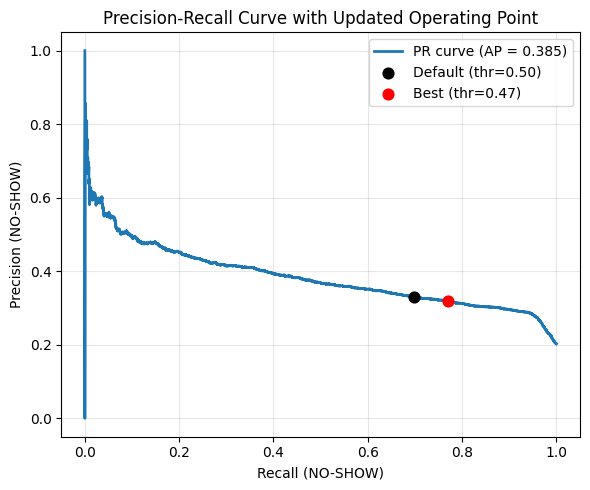

=== Default threshold (0.5) ===
Precision: 0.330
Recall: 0.698

=== Best threshold ===
Threshold: 0.47
Precision: 0.319
Recall: 0.770


In [67]:
# Predicted probabilities
y_scores = final_model.predict_proba(X_test)[:, 1]                  # probabilities for No_show = 1

# PR curve
precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_scores,
    pos_label=1                                                      # positive class of interest
)

ap = average_precision_score(y_test, y_scores)                      # average precision summary

# --- DEFAULT THRESHOLD (0.5)
thr_default = 0.5                                                    # standard classification threshold
y_pred_default = (y_scores >= thr_default).astype(int)              # predictions at default threshold

prec_default = precision_score(
    y_test, y_pred_default, pos_label=1, zero_division=0
)                                                                    # precision at threshold 0.50

rec_default = recall_score(
    y_test, y_pred_default, pos_label=1, zero_division=0
)                                                                    # recall at threshold 0.50

# --- BEST THRESHOLD from threshold analysis
thr_best = best_threshold                                            # previously selected F1-optimal threshold
y_pred_best = (y_scores >= thr_best).astype(int)                    # predictions at selected threshold

prec_best = precision_score(
    y_test, y_pred_best, pos_label=1, zero_division=0
)                                                                    # precision at best threshold

rec_best = recall_score(
    y_test, y_pred_best, pos_label=1, zero_division=0
)                                                                    # recall at best threshold

# --- Plot
plt.figure(figsize=(6, 5))
plt.plot(
    recall,
    precision,
    lw=2,
    label=f"PR curve (AP = {ap:.3f})"                                # full precision-recall curve
)

# Default point
plt.scatter(
    rec_default,
    prec_default,
    color="black",
    s=60,
    zorder=5,
    label="Default (thr=0.50)"                                       # operating point at standard threshold
)

# Best threshold point
plt.scatter(
    rec_best,
    prec_best,
    color="red",
    s=60,
    zorder=5,
    label=f"Best (thr={thr_best:.2f})"                               # operating point selected via F1
)

plt.xlabel("Recall (NO-SHOW)")
plt.ylabel("Precision (NO-SHOW)")
plt.title("Precision-Recall Curve with Updated Operating Point")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print comparison
print("=== Default threshold (0.5) ===")
print(f"Precision: {prec_default:.3f}")
print(f"Recall: {rec_default:.3f}")

print("\n=== Best threshold ===")
print(f"Threshold: {thr_best:.2f}")
print(f"Precision: {prec_best:.3f}")
print(f"Recall: {rec_best:.3f}")

At the default threshold of 0\.50, recall is approximately 0\.698 and precision is approximately 0\.330\. At the selected threshold of 0\.47, recall increases to approximately 0\.770, while precision becomes approximately 0\.3109\.

The selected threshold therefore moves the operating point toward a more recall oriented behavior\. This means that the model identifies a larger share of patients at risk of missing their appointment, accepting a small loss in precision\.

### Confusion matrix

The confusion matrix shows the complete breakdwon of prediction outcomes obtained at the selected threshold\. Since No\_show=1 is the postive class, it directly reveals how many missed appointments are correctly detected and how many attending patients are incorrectly flagged\.

The matrix reveals four key quantities:

- True Negatives \(TN\): correctly predicted "show"

- False Positives \(FP\): predicted "no\-show", but actually "show"

- False Negatives \(FN\): predicted "show", but actually "no\-show"

- True Positives \(TP\): correctly predicted "no\-show"

Confusion Matrix (best threshold):
[[9946 7116]
 [ 999 3336]]


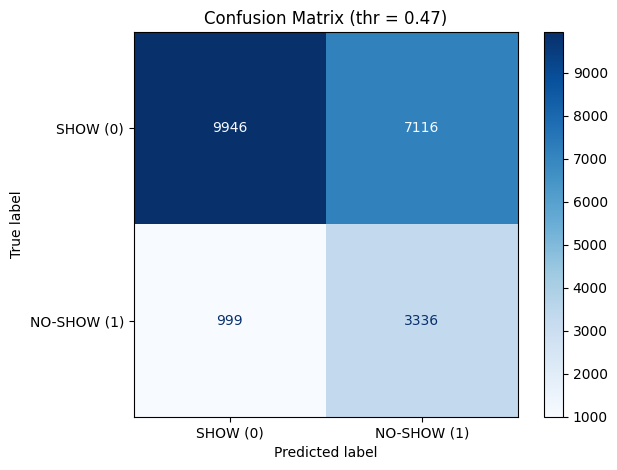

TN (correct SHOW): 9946
FP (false NO-SHOW): 7116
FN (missed NO-SHOW): 999
TP (correct NO-SHOW): 3336


In [68]:
# Confusion matrix with NO-SHOW = 1 as the positive class
# Use best threshold from threshold analysis
thr_best = best_threshold                                            # selected decision threshold

# Predictions with best threshold
y_pred_best = (y_scores >= thr_best).astype(int)                    # final threshold-adjusted predictions

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)                           # compare true and predicted labels

print("Confusion Matrix (best threshold):")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["SHOW (0)", "NO-SHOW (1)"]                       # explicit class interpretation
)
disp.plot(cmap="Blues")

plt.title(f"Confusion Matrix (thr = {thr_best:.2f})")
plt.grid(False)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()                                         # unpack confusion matrix entries

print(f"TN (correct SHOW): {tn}")
print(f"FP (false NO-SHOW): {fp}")
print(f"FN (missed NO-SHOW): {fn}")
print(f"TP (correct NO-SHOW): {tp}")

### False Positive Rate \(FPR\)

The False Positive Rate  measures the faction of actual show patients that are incorrectly classified as no\-show\. 

<img src="image-20260213-224404.png" width="" align="" />

In [69]:
# Predictions with best threshold from the previous analysis
y_pred_best = (y_scores >= best_threshold).astype(int)              # threshold-adjusted predictions

# Confusion matrix entries
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()      # retrieve TN, FP, FN and TP

# --- FPR (False Positive Rate)
fpr = fp / (fp + tn)                                                 # share of actual SHOW cases flagged as NO-SHOW

# Print result
print(f"FPR (best threshold): {fpr:.3f}")



FPR (best threshold): 0.417


At the selected threshold, the FPR is approximately 0\.417, meaning that about \*\*42% of attending patients\*\* are flagged as being at risk of missing their appointment\.

This value is relatively high and should be explicitly considered when interpreting the model\. The chosen threshold improves no\-show detection, but it also increases of false alerts\. This further supports the ude of the model as a prioritization aid rather than as a stand\-alone decision system\.

### Matthews Correlation Coefficient \(MCC\)

The Matthews Correlation Coefficient provides a balanced evaluation of binary classification performance by combining all four entries of the confusion matrix\. It remains informative under class imbalance, unlike accuracy\.

In [70]:
# MCC (Matthews Correlation Coefficient)
mcc = matthews_corrcoef(y_test, y_pred_best)                         # balanced correlation-based classification metric

print("Matthews Correlation Coefficient (MCC):", mcc)

Matthews Correlation Coefficient (MCC): 0.28342628218571425


# Error Analysis

To better understand the limitations of the model beyond aggregate metrics, an error analysis is conducted\. The objective is to identify systematic patterns in false positive and false negatives, and to assess whether misclassifications are consistent with the behavioral dynamics observed during exploratory analysis\.

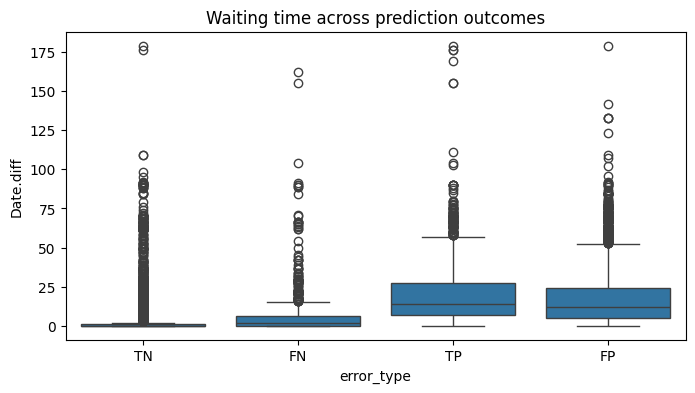

In [71]:
# Create error dataframe
y_pred_best = (y_scores >= best_threshold).astype(int)              # final predictions at the selected threshold

error_df = X_test.copy()                                             # preserve original test features
error_df["true"] = y_test.values                                    # true class label
error_df["pred"] = y_pred_best                                      # predicted class label

# Label prediction outcome
def get_error_type(row):
    if row["true"] == 1 and row["pred"] == 1:
        return "TP"                                                  # correctly detected no-show
    elif row["true"] == 1 and row["pred"] == 0:
        return "FN"                                                  # missed no-show
    elif row["true"] == 0 and row["pred"] == 1:
        return "FP"                                                  # false no-show alert
    else:
        return "TN"                                                  # correctly detected show

error_df["error_type"] = error_df.apply(
    get_error_type,
    axis=1
)                                                                    # assign prediction outcome to each test case

# Plot
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=error_df,
    x="error_type",
    y="Date.diff"
)                                                                    # compare waiting time across prediction outcomes
plt.title("Waiting time across prediction outcomes")
plt.show()

The distribution of waiting time across prediction outcomes confirms that this feature plays a central role in the model\. True positives and false positives are associated with higher waiting times, indicating that long delays strongly push the model towards predicting no\-shows\. In contrast, false negatives are mostly concentrated at lower waiting times, suggesting that some no\-shows occur even in seemingly low\-risk situations\.

# Explainable AI for No\-show Prediction

After evaluating predictive performance, the analysis moves to explainability in order to understand why the final model produces its predictions\.

This step is importnat because good aggregate performance alone is not sufficient, especially in a healthcare\-related problem\. It is also necessary to verify whether the model relies on plausible pattenrs and whether its behavior is consistent with the relationships observed during exploratory analysis\.

In this project, explainability is addressed through SHAP, which provides both global and local interpretations\. Globally, SHAP identifies which transformed features have the largest impact on the model's output across many patients\. Locally, it explains how specific features push an individual prediction toward show or no show\.

This makes SHAP particularly useful here, because the final model is non\-linear and built on top of\. atransformed feature space that includes imputed, scaled, encoded and engineeered variables\. As a aresult, model interpretation cannot rely only on raw coefficients or feature importances\.

## SHAP Analysis

Before computing SHAP values, the fitted preprocessing block and the fitted classifier are extracted from the final pipeline\. 

This is necessary because the classifier does not operate on the raw input table, but on the transformed feature matrix produced by the preprocessor\. Therefore, SHAP must be computed on the same transformed representation that is actually seen by the final model\.

The point is methodologically important: the explanation must match the model's real input space\. Explaining raw variables directly would be misleading if the classifier is trained on encoded and transformed features instead\.

The test set is then transformed using the fitted preprocessor\. This ensures that the observations used for explanation are represented in exactly the same way as they were during prediction\.

In [72]:
# Extract fitted preprocessor and fitted classifier from the final pipeline
fitted_preprocessor = final_model.named_steps["preprocessor"]       # preprocessing block fitted during model training
fitted_classifier = final_model.named_steps["classifier"]           # final trained XGBoost estimator

# Transform the test set
X_test_transformed = fitted_preprocessor.transform(X_test)          # model-ready representation used for SHAP

Since the transformed matrix is difficult to read in raw numeric form, transformed feature names are extracted and the matrix is converted into a DataFrame\. This improves interpretability and makes SHAP outputs much easier to inspect\.

It is particularly useful here because the preprocessor generates renamed features from multiple sources: scaled numerics, binary indicators, one\-hot encoded categories and engineere datetime components\.

In [73]:
# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()         # names of encoded and engineered features

# Convert transformed matrix to DataFrame for readability
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,                                           # preserve interpretable feature labels
    index=X_test.index                                               # keep original test-set indexing
)

A SHAP explainer is then created for the fitted tree\-based classifier\. SInce the final model is XGBoost, TreeExplainer is the appropriate and computationally efficient choice\.

SHAP values quantify how much each transformed feature contributes to moving the prediction away from the model's baseline output\. Positive contributions push the prediction toward the no\-show class, while negative contributions push it toward the show class\-

In [74]:
# Tree-based SHAP explainer for the fitted XGBoost classifier
explainer = shap.TreeExplainer(fitted_classifier)                   # efficient SHAP explainer for tree ensembles

# Compute SHAP values on the transformed test representation
shap_values = explainer.shap_values(X_test_transformed_df)          # contribution of each feature to predictions

### SHAP summary plot: beeswarm

The SHAP summary plot provides a global view fo feature importance and direction effect\.

Each point corresponfs to one patient and one feature contribution\. Features are ordered by average absolute SHAP magnitude, so the most influential transformed variable appear at the top\. The horizontal position indicates whether the feature puses the prediction toward no show or toward show, while the colore encodes the actual feature value\.

This plot is particularly useful because it combines two kinds of information at once: global importance and directional behavior\.

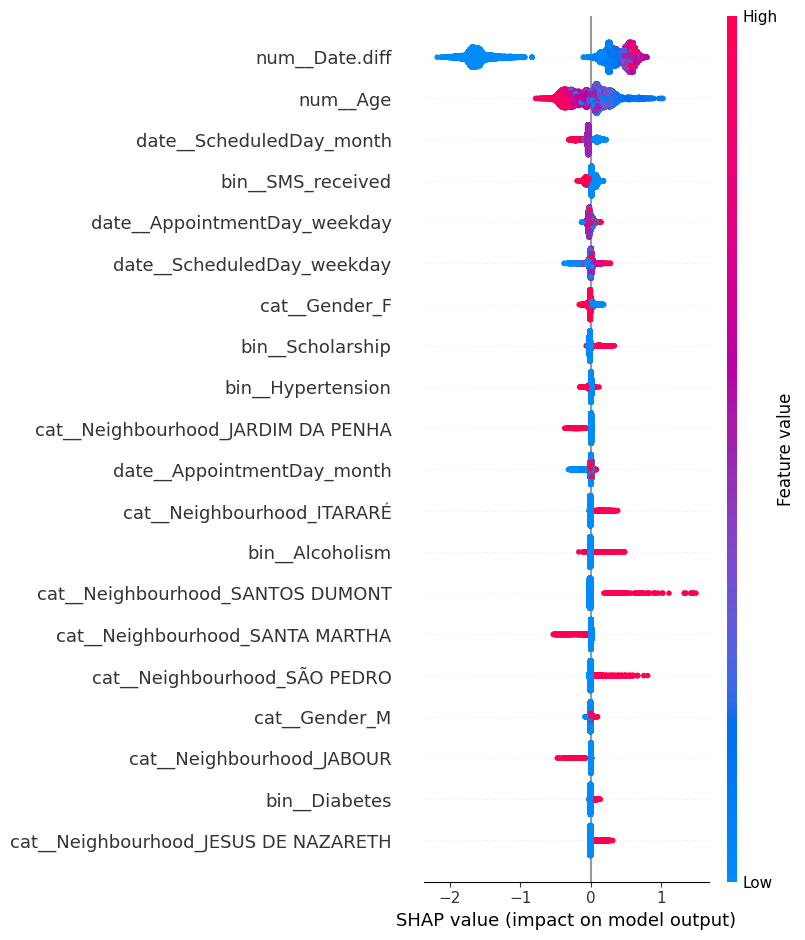

In [75]:
# Global SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_transformed_df       # show magnitude, direction and feature values
)

The summary plot shows that num\_Date\.diff is by far the most influential feature in the final model\. This result confirms that waiting time remains the central predictive driver even after full preprocessing and modeling pipeline\.

This is fully coherent with the earlier exploratory analysis and the error analysis\. Long waiting times consistently push predictions toward the no\-show class, while shorter waiting times push predictions toward the show class\. In other words, the model is relying heavily on the same behavioral structure that emerged earlier in the notebook\.

Age appears as the second most important feature, although with a clearly smaller effect than waiting time\. This suggests that age contributes useful additional signal, but is not the main driver of prediction\. 

### SHAP bar plot

The SHAP bar plot summarizes the average absolute importance of each transformed feature, without showing the direction of the effect\.

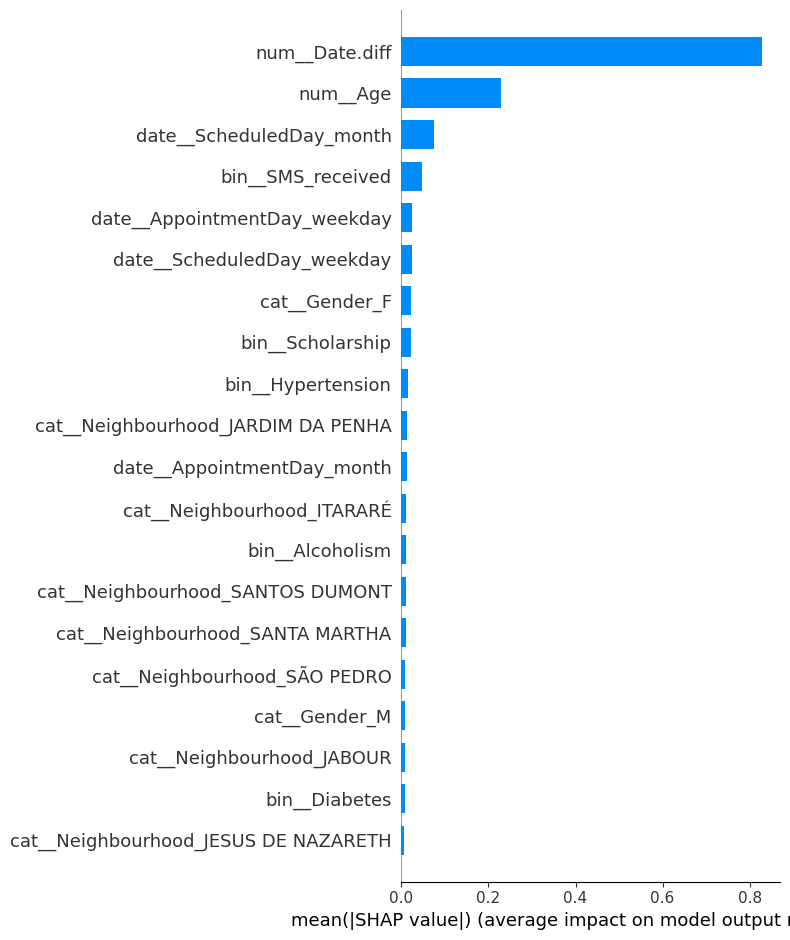

In [76]:
# Global mean absolute SHAP importance
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    plot_type="bar"        # rank features by average contribution magnitude
)

It confirms the same hierarchy observed in the beeswarm plot: waiting time is the dominant predictor, followed by age, while all remaining variables have substantially smaller contributions\.

The agreement between the two global SHAP visualizations strengthens the interpretation of the final model\. Its predictions are mainly driven by a clear and plausible behavioural stage, supported by secondary temporal and contextual features\.

### SHAP waterfall plot

The waterfall plot provides a local explanation for one individual prediction\. Starting from the model’s baseline output, it shows how each feature pushes the final prediction upward or downward\.

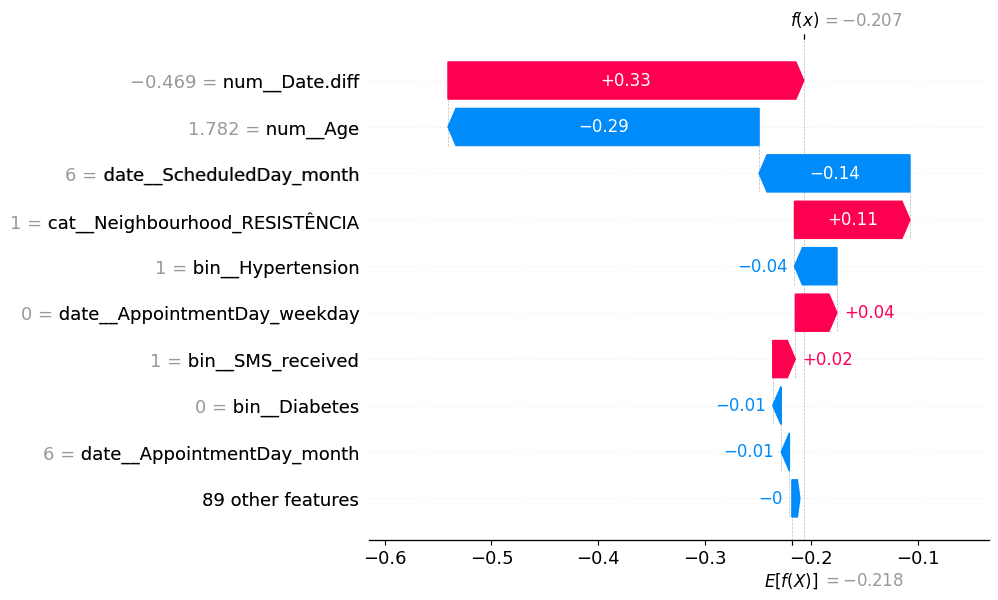

In [77]:
# Example: explain one individual patient
idx = 0                                                    # selected test observation

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],                             # feature-level contributions for this patient
        base_values=explainer.expected_value,                # model baseline output
        data=X_test_transformed_df.iloc[idx],                # transformed feature values of the patient
        feature_names=X_test_transformed_df.columns          # readable transformed feature names
    )
)

In the displayed example, waiting time contributes toward the no\-show direction, while age and the scheduled\-month feature push the prediction in the opposite direction\. Smaller effects are produced by additional variables such as neighbourhood, hypertension and SMS reception\.

The final output results from the combination of these contributions rather than from a single feature alone\. This local explanation complements the global SHAP plots by showing how the model builds an individual prediction patient by patient\.

# Conclusion

This project developed an end\-to\-end machine learning pipeline for predicting medical appointment no\-shows, with particular attention to class imbalance, leakage\-free preprocessing and reliable model selection

# Limitations and Future Improvements

The main limitation of the project is that no\-show behavior is only partially observable from the available variables\. Factors such as previous attendane history, distance from the clinic, work constraints, appointment urgency or more detailed socioeconomic information are not included and this is likely limits the achievable predictive performance\. 

A second limitation concerns the operating trade\-off of the final model\. The selected threshold increases recall for no\-shows, but also produces a relatively high False Positive Rate\. This makes the model more suitable for soft interventions, such as reminders or follow\-up prioritization, than for high impact automatic decisions\.

Future work could extend the analysis by incorporating richer patient and appointment history, evaluating cost\-sensitive threshold selection instead of relying only on F1\-score, assessing probability calibration and validating the model on data from a different time period or healthcare setting\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1257f757-56a4-4ac3-ac6e-de077b08afab' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>